# Aprendizaje Automatico 1 — TP Nº 2 

Integrantes: Quinteros, Lasarte, Lazarte

# 0 — Importación de Librerias

In [ ]:
# Librerías estándar de Python
import time
import math

# Librerías de terceros (Core Data Science & ML)
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from pycaret.tasks import ClassificationExperiment

# Componentes específicos de Scikit-Learn (Preprocesamiento, Selección de Modelos y Métricas)
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, auc, classification_report, confusion_matrix, 
    f1_score, matthews_corrcoef, precision_score, recall_score, roc_curve
)
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, StratifiedKFold, 
    cross_val_score, train_test_split
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier

import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import r2_score

# 1 — Análisis Descriptivo

Columnas:


*   Date (Temporal): Fecha del registro (formato año-mes-día).
*   Location (Catagórica): Ciudad meteorológica donde se tomó la medición.
*   MinTemp (Numérica): Temperatura mínima del día (°C).
*   MaxTemp (Numérica): Temperatura máxima del día (°C).
*   Rainfall (Numérica): Cantidad de lluvia caída en el día (mm).
*   Evaporatio (Numérica): Cantidad de agua evaporada (mm).
*   Sunshine (Numérica): Horas de sol durante el día.
*   WindGustDir (Catagórica): Dirección de la ráfaga de viento más fuerte.
*   WindGustSpeed (Numérica): Velocidad máxima de ráfaga de viento (km/h).
*   WindDir9am (Catagórica): Dirección del viento a las 9 am.
*   WindDir3pm (Catagórica): Dirección del viento a las 3 pm.
*   WindSpeed9am (Numérica): Velocidad del viento a las 9 am.
*   WindSpeed3pm (Numérica): Velocidad del viento a las 3 pm.
*   Humidity9am (Numérica): Humedad relativa (%) a las 9 am.
*   Humidity3pm (Numérica): Humedad relativa (%) a las 3 pm.
*   Pressure9am (Numérica): Presión atmosférica (hPa) a las 9 am.
*   Pressure3pm (Numérica): Presión atmosférica (hPa) a las 3 pm.
*   Cloud9am (Numérica): Nubosidad a las 9 am (escala de 0 a 8, donde 8 es cielo totalmente cubierto).
*   Cloud3pm (Numérica): Nubosidad a las 3 pm.
*   Temp9am (Numérica): Temperatura medida a las 9 am.
*   Temp3pm (Numérica): Temperatura medida a las 3 pm.
*   RainToday (Catagórica): Indica si llovió ese día (Yes/No).
*   RainTomorrow (Catagórica): Indica si va a llover al día siguiente.
*   RainfallTomorrow (Numérica): Cantidad de lluvia del día siguiente (mm).



In [2]:
clima = pd.read_csv('weatherAUS_2026C1.csv')

In [3]:
clima.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [4]:
clima.info()

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  str    
 2   Location          145412 non-null  str    
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  str    
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  str    
 11  WindDir3pm        141186 non-null  str    
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       130351 non-nu

In [5]:
clima.describe()

,Unnamed: 0,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainfallTomorrow
count,145412.000000,143928.000000,144159.000000,142152.000000,82658.000000,75616.000000,135159.000000,143645.000000,142351.000000,142759.000000,140907.000000,130351.000000,130388.000000,89542.000000,86076.000000,143646.000000,141805.000000,142153.000000
mean,72728.184393,12.196528,23.223064,2.361516,5.468616,7.611241,40.036668,14.067277,18.661899,68.861521,51.532206,1017.647237,1015.255080,4.447287,4.509770,16.991981,21.683360,2.361242
std,41990.722236,6.417956,7.135927,8.479338,4.193871,3.785612,13.648259,8.936768,8.865457,19.062866,20.844414,7.113833,7.044507,2.887161,2.720306,6.509191,6.953072,8.479084
min,0.000000,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,0.000000
25%,36362.750000,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,12.000000,57.000000,36.600000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,72727.500000,12.000000,22.600000,0.000000,4.800000,8.400000,38.000000,13.000000,18.000000,69.900000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,109093.250000,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.100000,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,145458.000000,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,130.000000,86.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,9.000000,39.800000,47.000000,371.000000


In [6]:
clima = clima.drop('Unnamed: 0', axis = 1) # Se borra porque es simplemente un índice (contador de filas). No aporta información meteorológica.

In [7]:
clima.head(1)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0


## Distribución de los Datos Antes de la Limpieza

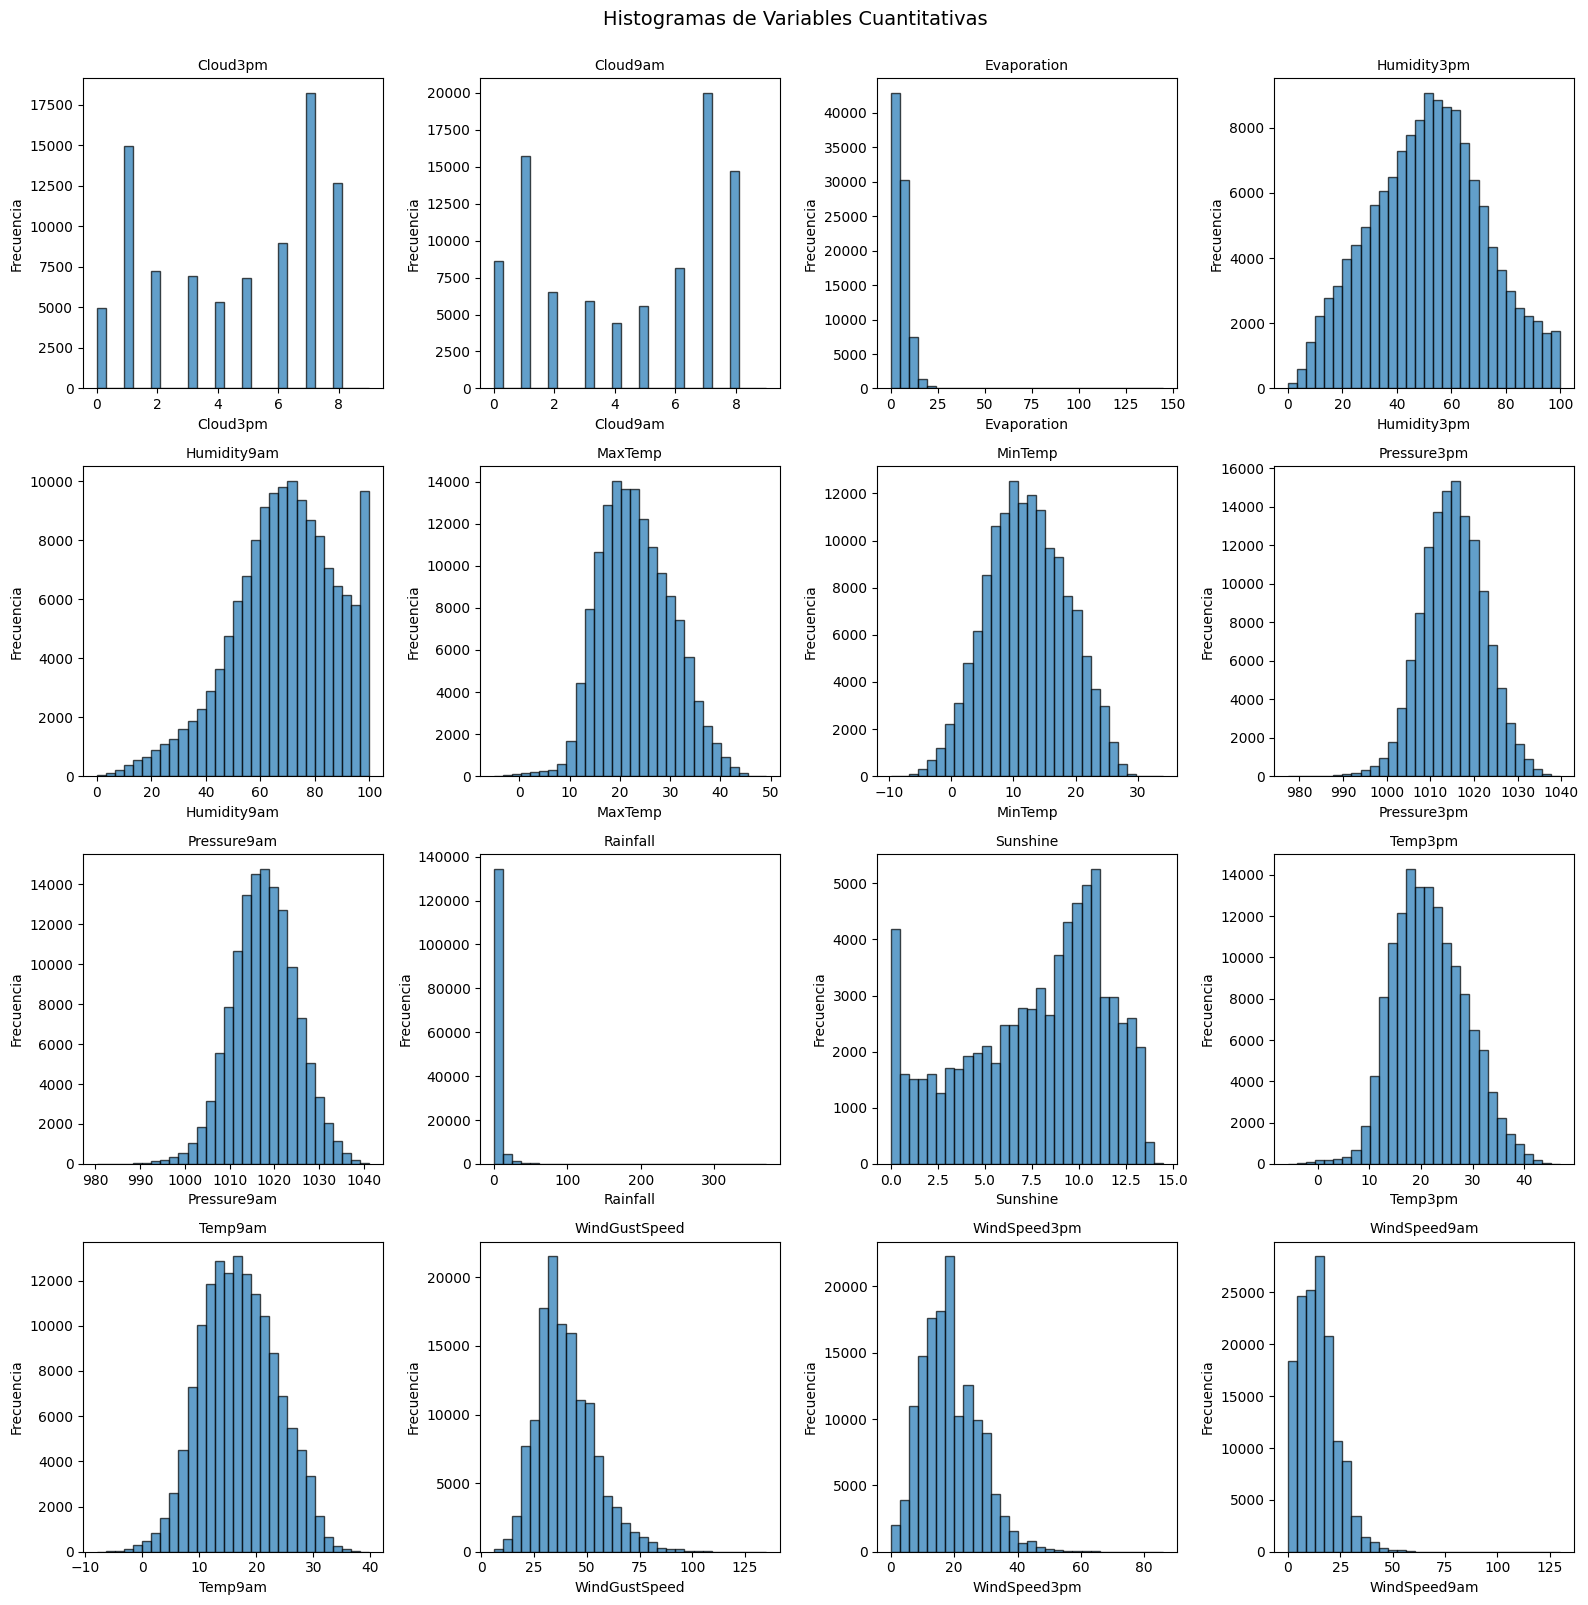

In [8]:
cols_num = clima.select_dtypes(include=['int64', 'float64']).columns.difference(['RainfallTomorrow'])
n_cols = len(cols_num)
n_rows = math.ceil(n_cols / 4)  # 4 columnas, filas dinámicas

fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_num):
  axes[i].hist(clima[col].dropna(), bins=30, edgecolor='black', alpha=0.7), 
  axes[i].set_title(col, fontsize=10)
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Frecuencia')

# Ocultar los ejes no utilizados
for j in range(len(cols_num), len(axes)):
  axes[j].axis('off')

plt.suptitle('Histogramas de Variables Cuantitativas', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

Este gráfico muestra la distribución de las variables numéricas del conjunto de datos mediante histogramas de frecuencias:
* Comportamiento Normal (Simétrico): Variables como MaxTemp, MinTemp, Temp3pm, Temp9am, Humidity3pm, Pressure3pm y Pressure9am siguen una distribución aproximadamente gaussiana o de campana.
* Sesgo a la Izquierda: Humidity9am muestra una concentración de datos hacia los valores más altos (humedad alta por la mañana).
* Sesgo a la Derecha (Exponencial): Evaporation, Rainfall, WindGustSpeed, WindSpeed3pm y WindSpeed9am presentan una fuerte asimetría positiva, donde la gran mayoría de los registros se concentran en valores bajos (p. ej., días sin lluvia o con poco viento).
* Distribución Bimodal / Uniforme: Sunshine muestra picos en los extremos (muchas horas de sol o muy pocas).
* Variables Discretas: Cloud3pm y Cloud9am se comportan como variables categóricas ordinales o discretas bien definidas (escala de octas de cobertura nubosa).

In [9]:
print("Cantidad de valores NaN:")
print(f"\n{clima.isnull().sum().sort_values(ascending=False)}")

Cantidad de valores NaN:

Sunshine            69796
Evaporation         62754
Cloud3pm            59336
Cloud9am            55870
Pressure9am         15061
Pressure3pm         15024
WindDir9am          10562
WindGustDir         10316
WindGustSpeed       10253
Humidity3pm          4505
WindDir3pm           4226
Temp3pm              3607
RainToday            3260
Rainfall             3260
RainfallTomorrow     3259
RainTomorrow         3259
WindSpeed3pm         3061
Humidity9am          2653
WindSpeed9am         1767
Temp9am              1766
MinTemp              1484
MaxTemp              1253
Location                0
Date                    0
dtype: int64


In [10]:
# Porcentaje de valores nulos por variable
print("Porcentaje de valores NaN:")
print(f"\n{((clima.isnull().sum() / len(clima)) * 100).sort_values(ascending=False)}")

Porcentaje de valores NaN:

Sunshine            47.998790
Evaporation         43.155998
Cloud3pm            40.805436
Cloud9am            38.421863
Pressure9am         10.357467
Pressure3pm         10.332022
WindDir9am           7.263500
WindGustDir          7.094325
WindGustSpeed        7.051000
Humidity3pm          3.098094
WindDir3pm           2.906225
Temp3pm              2.480538
RainToday            2.241906
Rainfall             2.241906
RainfallTomorrow     2.241218
RainTomorrow         2.241218
WindSpeed3pm         2.105053
Humidity9am          1.824471
WindSpeed9am         1.215168
Temp9am              1.214480
MinTemp              1.020549
MaxTemp              0.861690
Location             0.000000
Date                 0.000000
dtype: float64


In [11]:
outliers = {}

# Solo columnas numéricas
cols_num = clima.select_dtypes(include=['int64', 'float64']).columns

for col in cols_num:
  Q1 = clima[col].quantile(0.25)
  Q3 = clima[col].quantile(0.75)
  IQR = Q3 - Q1

  limite_inf = Q1 - 1.5 * IQR
  limite_sup = Q3 + 1.5 * IQR

  cantidad = ((clima[col] < limite_inf) | (clima[col] > limite_sup)).sum()

  outliers[col] = cantidad

# Convertimos a DataFrame para verlo prolijo
df_outliers = pd.DataFrame.from_dict(outliers, orient='index', columns=['Cantidad_atipicos'])

print(df_outliers.sort_values(by='Cantidad_atipicos', ascending=False))

                  Cantidad_atipicos
Rainfall                      25574
RainfallTomorrow              25571
WindGustSpeed                  2978
Evaporation                    1995
WindSpeed9am                   1972
WindSpeed3pm                   1709
Humidity9am                    1495
Pressure9am                    1199
Pressure3pm                     926
Temp3pm                         783
MaxTemp                         514
Temp9am                         270
MinTemp                          56
Sunshine                          0
Humidity3pm                       0
Cloud9am                          0
Cloud3pm                          0


## Pre-procesamiento para Data Leakage
Limpieza pre-split: sacamos columnas leakage, filas sin target y encodeamos


In [12]:
clima = clima.drop(columns=['RainfallTomorrow'])
clima = clima.dropna(subset=['RainTomorrow'])
clima['RainTomorrow'] = clima['RainTomorrow'].map({'No': 0, 'Yes': 1}).astype(int)

In [13]:
clima.info()

<class 'pandas.DataFrame'>
Index: 142153 entries, 0 to 145411
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142153 non-null  str    
 1   Location       142153 non-null  str    
 2   MinTemp        141516 non-null  float64
 3   MaxTemp        141831 non-null  float64
 4   Rainfall       140747 non-null  float64
 5   Evaporation    81341 non-null   float64
 6   Sunshine       74368 non-null   float64
 7   WindGustDir    132825 non-null  str    
 8   WindGustSpeed  132885 non-null  float64
 9   WindDir9am     132144 non-null  str    
 10  WindDir3pm     138377 non-null  str    
 11  WindSpeed9am   140805 non-null  float64
 12  WindSpeed3pm   139524 non-null  float64
 13  Humidity9am    140379 non-null  float64
 14  Humidity3pm    138544 non-null  float64
 15  Pressure9am    128143 non-null  float64
 16  Pressure3pm    128176 non-null  float64
 17  Cloud9am       88512 non-null   float64
 18  

In [14]:
# Extraemos Month de Date y lo encodeamos cíclico para el modelo
clima['Date'] = pd.to_datetime(clima['Date'])
clima['Month'] = clima['Date'].dt.month
clima['Month_sin'] = np.sin(2 * np.pi * clima['Date'].dt.month / 12)
clima['Month_cos'] = np.cos(2 * np.pi * clima['Date'].dt.month / 12)
clima = clima.drop(columns=['Date'])

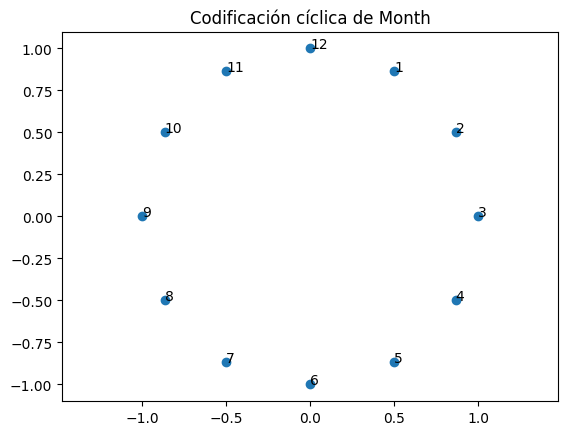

In [15]:
months_test = np.arange(1, 13)
plt.scatter(np.sin(2*np.pi*months_test/12), np.cos(2*np.pi*months_test/12))
for m in months_test:
  plt.annotate(str(m), (np.sin(2*np.pi*m/12), np.cos(2*np.pi*m/12)))
plt.title('Codificación cíclica de Month')
plt.axis('equal')
plt.show()

Dividimos los datos en conjuntos de entrenamiento (80%) y prueba (20%) para evaluar el rendimiento del modelo.

In [16]:
# Separamos features y targets
X = clima.drop(columns=['RainTomorrow'])
y = clima['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(113722, 24) (28431, 24)


## Visualizaciones de Variables

Visualizamos la dispersion y presencia de outliers

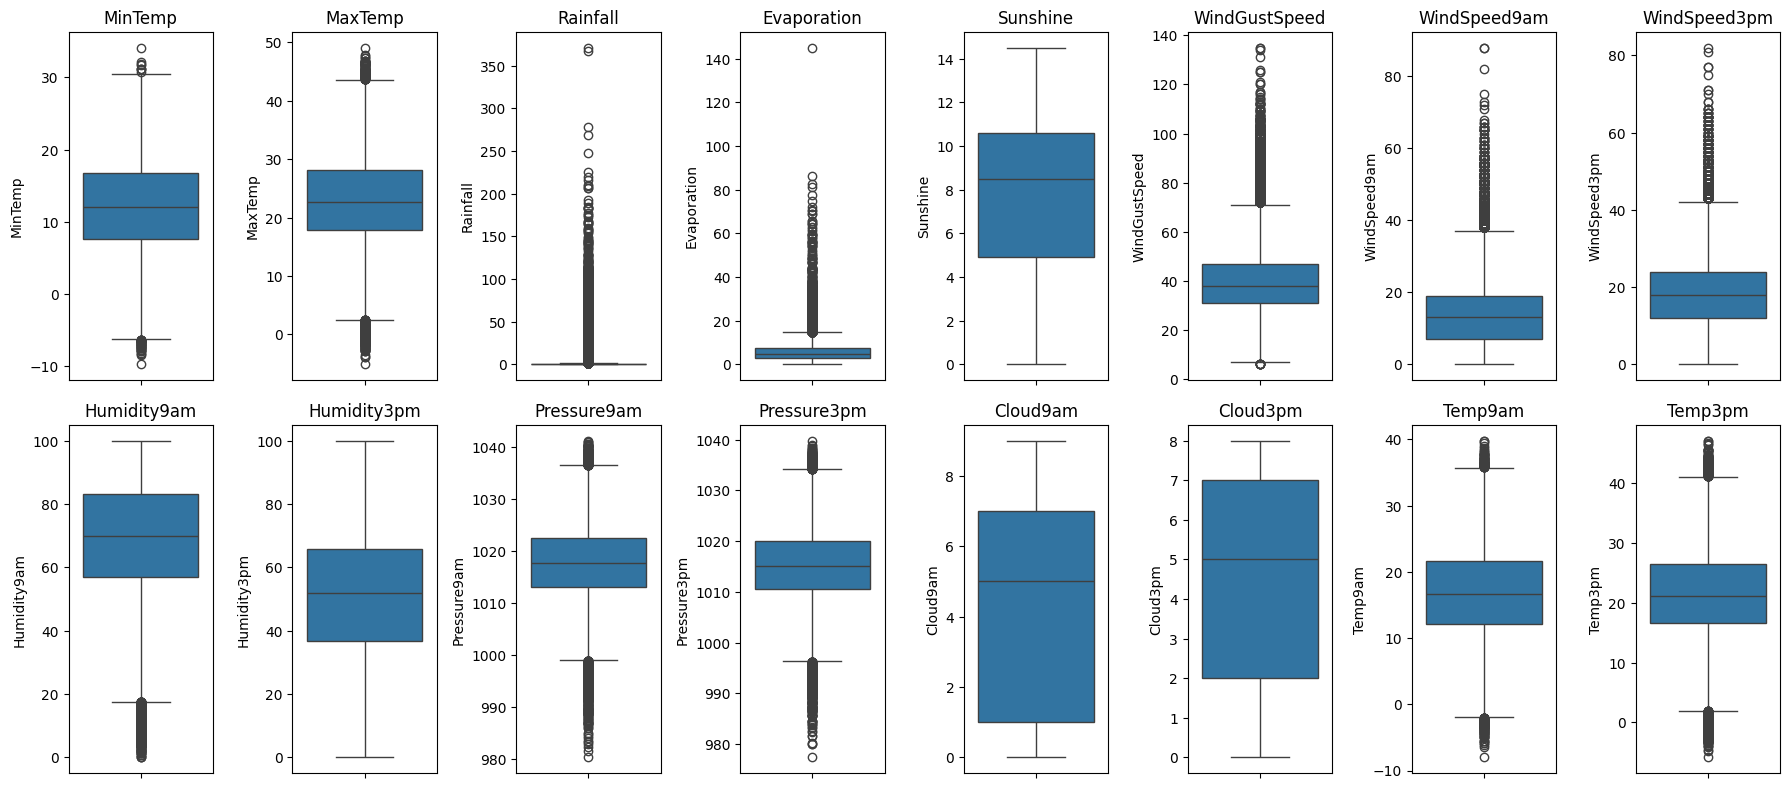

In [17]:
X_train_num = X_train.select_dtypes(include=['int64', 'float64'])

X_train_num = X_train_num.drop(columns=['Month_cos', 'Month_sin'], errors='ignore')

fig, ax = plt.subplots(2, 8, figsize=(18,8))

for i, col in enumerate(X_train_num.columns):
  sns.boxplot(y=X_train_num[col], ax=ax.flatten()[i])
  ax.flatten()[i].set_title(col)

plt.tight_layout()
plt.show()

Este gráfico de diagramas de caja (boxplots) permite visualizar la dispersión, la simetría y la presencia de valores atípicos (outliers) en las variables numéricas:
* Alta Presencia de Outliers: Variables como Rainfall, Evaporation, WindGustSpeed, WindSpeed9am y WindSpeed3pm muestran una gran cantidad de valores atípicos en el extremo superior. Esto es consistente con el sesgo a la derecha observado en los histogramas (eventos extremos de lluvia o viento fuerte).
* Outliers en Ambos Extremos: Las variables de temperatura (MinTemp, MaxTemp, Temp9am, Temp3pm) y presión (Pressure9am, Pressure3pm) presentan valores atípicos tanto en los máximos como en los mínimos, lo que refleja días con condiciones climáticas inusualmente frías, cálidas, de alta o baja presión.
* Sin Valores Atípicos: Las variables Sunshine, Cloud9am y Cloud3pm no registran outliers. Sus datos se distribuyen completamente dentro de los rangos esperados (p. ej., de 0 a 8 octas para la nubosidad).
* Distribución de Humedad: Humidity9am presenta valores atípicos únicamente en el extremo inferior (días con mañanas excepcionalmente secas), mientras que Humidity3pm muestra una dispersión más amplia y equilibrada sin valores atípicos marcados.

In [18]:
conteo = y_train.value_counts()
porcentaje = y_train.value_counts(normalize=True) * 100

print("Conteo:")
print(conteo)

print("\nPorcentaje:")
print(porcentaje)

Conteo:
RainTomorrow
0    88224
1    25498
Name: count, dtype: int64

Porcentaje:
RainTomorrow
0    77.578657
1    22.421343
Name: proportion, dtype: float64


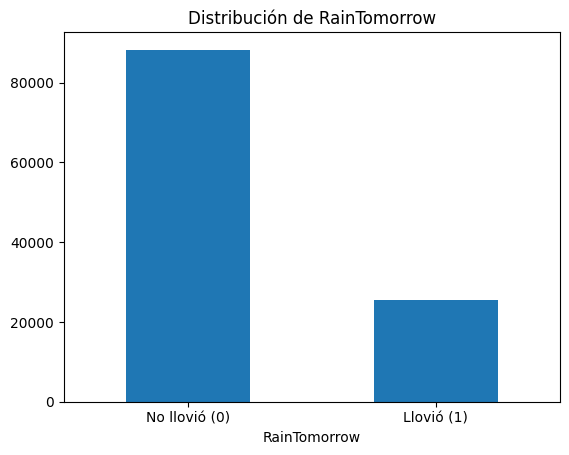

In [19]:
y_train.value_counts().plot(kind='bar')
plt.title('Distribución de RainTomorrow')
plt.xticks([0, 1], ['No llovió (0)', 'Llovió (1)'], rotation=0)
plt.xlabel('RainTomorrow')
plt.show()

El Dataset está claramente desbalanceado, por lo que se deberá tener en cuenta más adelante.

Generamos un heatmap previa imputación para analizar la correlacion.

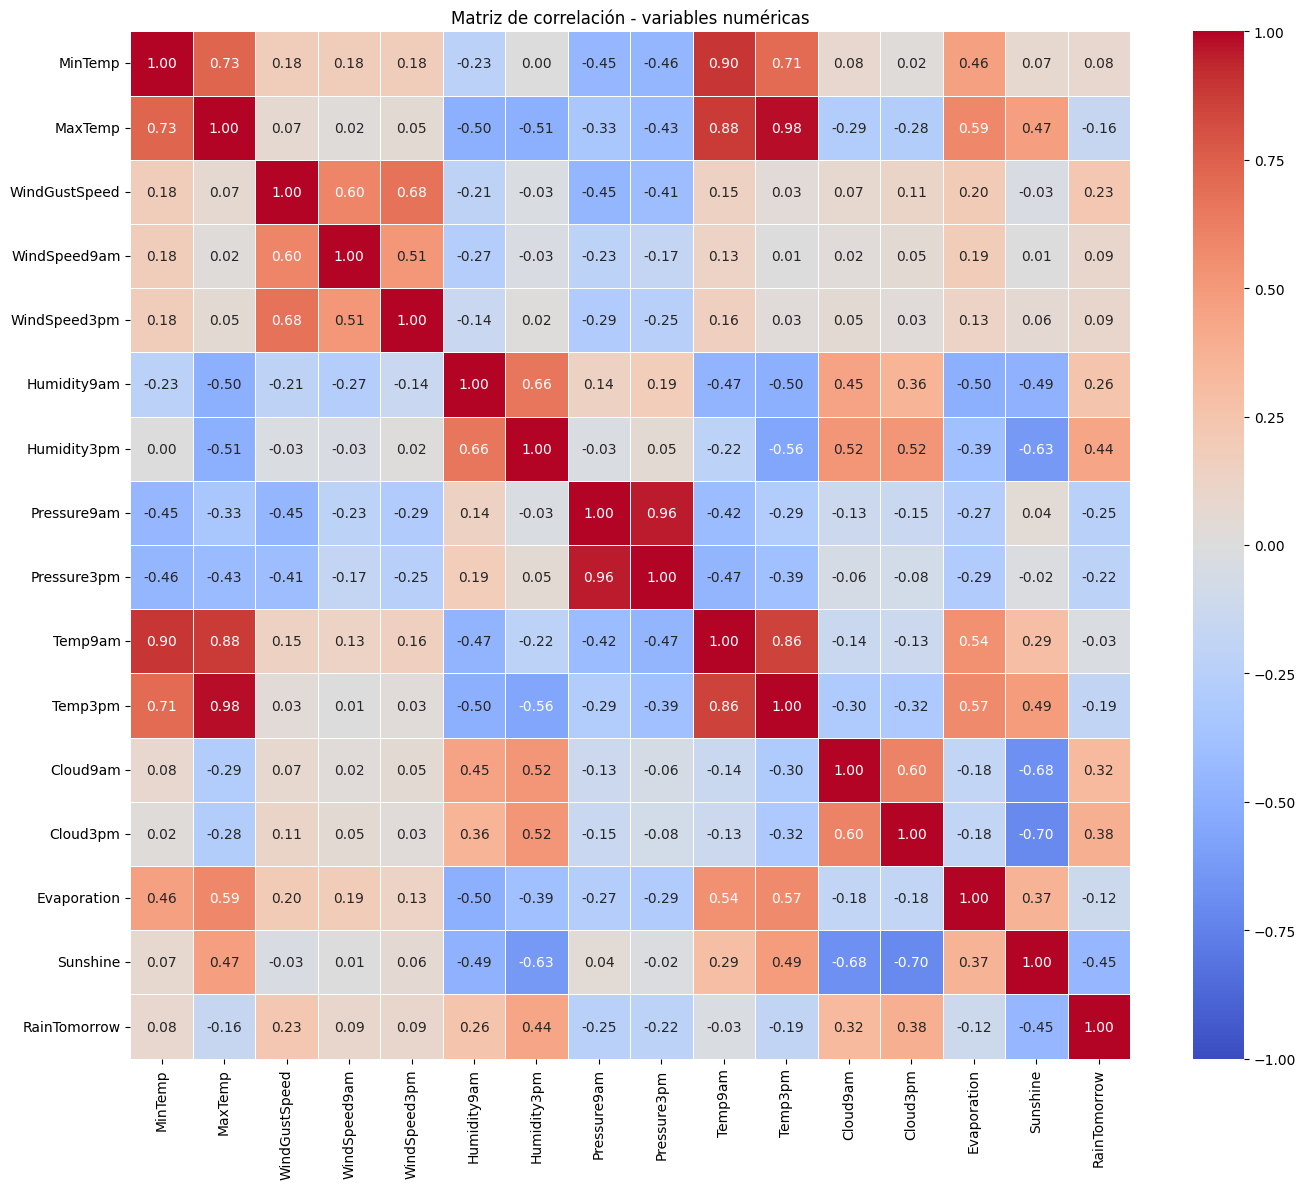

In [20]:
# Matriz de correlación
vars_num = ['MinTemp', 'MaxTemp', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
            'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
            'Temp9am', 'Temp3pm', 'Cloud9am', 'Cloud3pm', 'Evaporation', 'Sunshine']

data_corr = pd.concat([X_train[vars_num], y_train], axis=1)

corr1 = data_corr.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr1, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, center=0, vmin=-1,vmax=1)

plt.title('Matriz de correlación - variables numéricas')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Se observa una fuerte colinealidad natural entre variables homólogas medidades en diferentes horarios y temperaturas relacionadas, destacando las parejas MaxTemp / Temp3pm (0.98), Pressure9am / Pressure3pm (0.96) y Temp9am / Temp3pm (0.86). Con respecto a la variable objetivo (RainTomorrow), la humedad de la tarde (Humidity3pm) presenta la mayor correlación positiva (0.44), mientras que las horas de sol (Sunshine) muestran la mayor correlación negativa (-0.45).

## Tratamiento de NaNs

* Se crean copias de los conjuntos de datos y se imputan valores lógicos por defecto para Rainfall (con 0) y RainToday (con "No").
* Se generan flags binarias (_missing) para registrar qué registros contenían valores nulos originales.
* Imputacion en cascada: Se imputan con la moda calculada de forma jerárquica (Mes por Localidad -> Localidad -> Moda global). Las temperaturas, humedades y velocidades de viento se imputan bajo la misma lógica jerárquica pero utilizando la mediana.
* Para variables complejas, climáticamente correlacionadas o con comportamiento discreto (Pressure9am, Pressure3pm, Evaporation, Sunshine, Cloud9am, Cloud3pm), se aplica un escalado estándar (StandardScaler) seguido de un KNNImputer con (k=5) para estimar los nulos basándose en observaciones similares.
* Los valores continuos estimados por KNN para Cloud9am y Cloud3pm se redondean y acotan (clip) al rango discreto original de 0 a 8 octas.
* RainToday se convierte a formato binario (1/0).
* Se descartan Location y Month tras cumplir su rol en la imputación por grupos.
* Las variables categóricas del viento se transforman mediante One-Hot Encoding, alineando finalmente las columnas de Train y Test para garantizar consistencia.

In [21]:
# 1. Copias iniciales
X1_train = X_train.copy()
X1_test = X_test.copy()


# 2. Imputaciones básicas
for X in [X1_train, X1_test]:
  X['Rainfall'] = X['Rainfall'].fillna(0)
  X['RainToday'] = X['RainToday'].fillna('No')


# 3. Creación de flags (_missing) para identificar nulos originales
cols_flag = ['Humidity9am','Humidity3pm', 'Pressure9am','Pressure3pm', 'Temp9am','Temp3pm', 'Cloud9am','Cloud3pm', 'Evaporation','Sunshine']

for c in cols_flag:
  X1_train[c + '_missing'] = X1_train[c].isna().astype(int)
  X1_test[c + '_missing'] = X1_test[c].isna().astype(int)


# 4. Funciones de imputación en cascada
def imputar_cascada(X, col, stat_loc_month, stat_loc, stat_global):
  keys = pd.MultiIndex.from_arrays([X['Location'].values, X['Month'].values])
  vals = stat_loc_month.reindex(keys).values
  
  X[col] = X[col].fillna(pd.Series(vals, index=X.index))
  X[col] = X[col].fillna(X['Location'].map(stat_loc))
  X[col] = X[col].fillna(stat_global)

# 4.a Variables categóricas del viento (Moda)
for c in ['WindGustDir','WindDir9am','WindDir3pm']:
  moda_global = X1_train[c].mode(dropna=True).iloc[0]
  
  modas_loc = X1_train.groupby('Location')[c].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else moda_global)
  modas_loc_month = X1_train.groupby(['Location','Month'])[c].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

  for X in [X1_train, X1_test]:
    imputar_cascada(X, c, modas_loc_month, modas_loc, moda_global)

# 4.b Variables numéricas estables (Mediana)
cols_mediana = ['MinTemp','MaxTemp', 'WindGustSpeed', 'WindSpeed9am','WindSpeed3pm', 'Humidity9am','Humidity3pm', 'Temp9am','Temp3pm']

for c in cols_mediana:
  med_global = X1_train[c].median()
  meds_loc = X1_train.groupby('Location')[c].median()
  meds_loc_month = X1_train.groupby(['Location','Month'])[c].median()

  for X in [X1_train, X1_test]:
    imputar_cascada(X, c, meds_loc_month, meds_loc, med_global)


# 5. Imputación KNN Avanzada (con escalado previo)
cols_knn = ['Pressure9am', 'Pressure3pm', 'Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']      # <- Agregamos las nubes acá

cols_contexto = cols_mediana + ['Rainfall'] + cols_knn

# 5.a Escalado previo al KNN
scaler = StandardScaler() # <-- Cambio 2: Usamos StandardScaler
X_train_scaled = scaler.fit_transform(X1_train[cols_contexto])
X_test_scaled = scaler.transform(X1_test[cols_contexto])

# 5.b Imputación
imputer = KNNImputer(n_neighbors=5)
train_imputed_scaled = imputer.fit_transform(X_train_scaled)
test_imputed_scaled = imputer.transform(X_test_scaled)

# 5.c Revertimos la escala a los valores originales
df_train_temp = pd.DataFrame(
    scaler.inverse_transform(train_imputed_scaled), 
    columns=cols_contexto, index=X1_train.index
)
df_test_temp = pd.DataFrame(
    scaler.inverse_transform(test_imputed_scaled), 
    columns=cols_contexto, index=X1_test.index
)

# 5.d Reemplazamos SOLO las columnas objetivo
X1_train[cols_knn] = df_train_temp[cols_knn]
X1_test[cols_knn] = df_test_temp[cols_knn]

# 5.e Ajuste final: Las nubes son categorías discretas (0 a 8 oktas)
for c in ['Cloud9am', 'Cloud3pm']:
  X1_train[c] = np.clip(np.round(X1_train[c]), 0, 8)
  X1_test[c] = np.clip(np.round(X1_test[c]), 0, 8)


# 6. Transformaciones Finales y One-Hot Encoding
for X in [X1_train, X1_test]:
  X['RainToday'] = X['RainToday'].map({'Yes': 1, 'No': 0}).astype(int)

X1_train = X1_train.drop(columns=['Location','Month'])
X1_test = X1_test.drop(columns=['Location','Month'])

X1_train = pd.get_dummies(X1_train, columns=['WindGustDir','WindDir9am','WindDir3pm'])

X1_test = pd.get_dummies(X1_test, columns=['WindGustDir','WindDir9am','WindDir3pm'])

# Alineamos las columnas por si alguna categoría del test no estaba en el train
X1_test = X1_test.reindex(columns=X1_train.columns, fill_value=0)


# 7. Verificación Final de Resultados
print('Shape final (Train vs Test):', X1_train.shape, X1_test.shape, '| Total NaN restantes:', X1_train.isnull().sum().sum(), X1_test.isnull().sum().sum())

Shape final (Train vs Test): (113722, 77) (28431, 77) | Total NaN restantes: 0 0


In [22]:
outliers = {}

# Solo columnas numéricas
cols_num = X1_train.select_dtypes(include=['int64', 'float64']).columns

for col in cols_num:
    Q1 = X1_train[col].quantile(0.25)
    Q3 = X1_train[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    cantidad = ((X1_train[col] < limite_inf) | 
                 (X1_train[col] > limite_sup)).sum()

    outliers[col] = cantidad

# Convertimos a DataFrame para verlo prolijo
df_outliers = pd.DataFrame.from_dict(outliers, orient='index', columns=['Cantidad_atipicos'])

print(df_outliers.sort_values(by='Cantidad_atipicos', ascending=False))

               Cantidad_atipicos
Rainfall                   22829
Evaporation                 3226
WindGustSpeed               2874
WindSpeed9am                1497
WindSpeed3pm                1308
Pressure9am                 1214
Humidity9am                 1159
Pressure3pm                  950
Temp3pm                      609
MaxTemp                      393
Temp9am                      202
MinTemp                       51
Month_sin                      0
Humidity3pm                    0
Cloud3pm                       0
Cloud9am                       0
Sunshine                       0
Month_cos                      0


Se observa una alta presencia de valores atípicos concentrados principalmente en la variable Rainfall (22.829 registros), seguida por la evaporación y la velocidad del viento. Esta distribución es normal y refleja la variabilidad climática real de Australia, donde las tormentas o ráfagas severas son eventos intensos pero puntuales dentro de un clima mayoritariamente seco.

In [23]:
print("Cantidad de valores NaN:")
print(f"{X1_train.isnull().sum().sum()}")

Cantidad de valores NaN:
0


## Distribución de los Datos Despues de la Limpieza

In [24]:
X1_test.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Humidity9am_missing,Humidity3pm_missing,Pressure9am_missing,Pressure3pm_missing,Temp9am_missing,Temp3pm_missing,Cloud9am_missing,Cloud3pm_missing,Evaporation_missing,Sunshine_missing
count,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,...,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000
mean,12.252052,23.294568,2.279209,5.213482,7.498205,39.971281,14.034452,18.599328,68.818049,51.430776,...,0.012205,0.024375,0.095635,0.095072,0.006226,0.018255,0.378179,0.400162,0.425521,0.473392
std,6.404800,7.141904,7.925567,3.675060,3.516427,13.207054,8.913141,8.875466,19.013404,20.780403,...,0.109802,0.154213,0.294095,0.293320,0.078658,0.133874,0.484941,0.489940,0.494431,0.499300
min,-7.600000,-3.800000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.700000,18.000000,0.000000,2.600000,4.960000,31.000000,7.000000,12.000000,57.000000,36.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12.100000,22.700000,0.000000,4.600000,8.100000,38.000000,13.000000,18.000000,69.700000,51.900000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.900000,28.300000,0.800000,6.940000,10.300000,47.000000,19.000000,24.000000,82.900000,65.400000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,31.600000,46.900000,240.000000,64.000000,14.100000,125.000000,130.000000,86.000000,100.000000,100.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


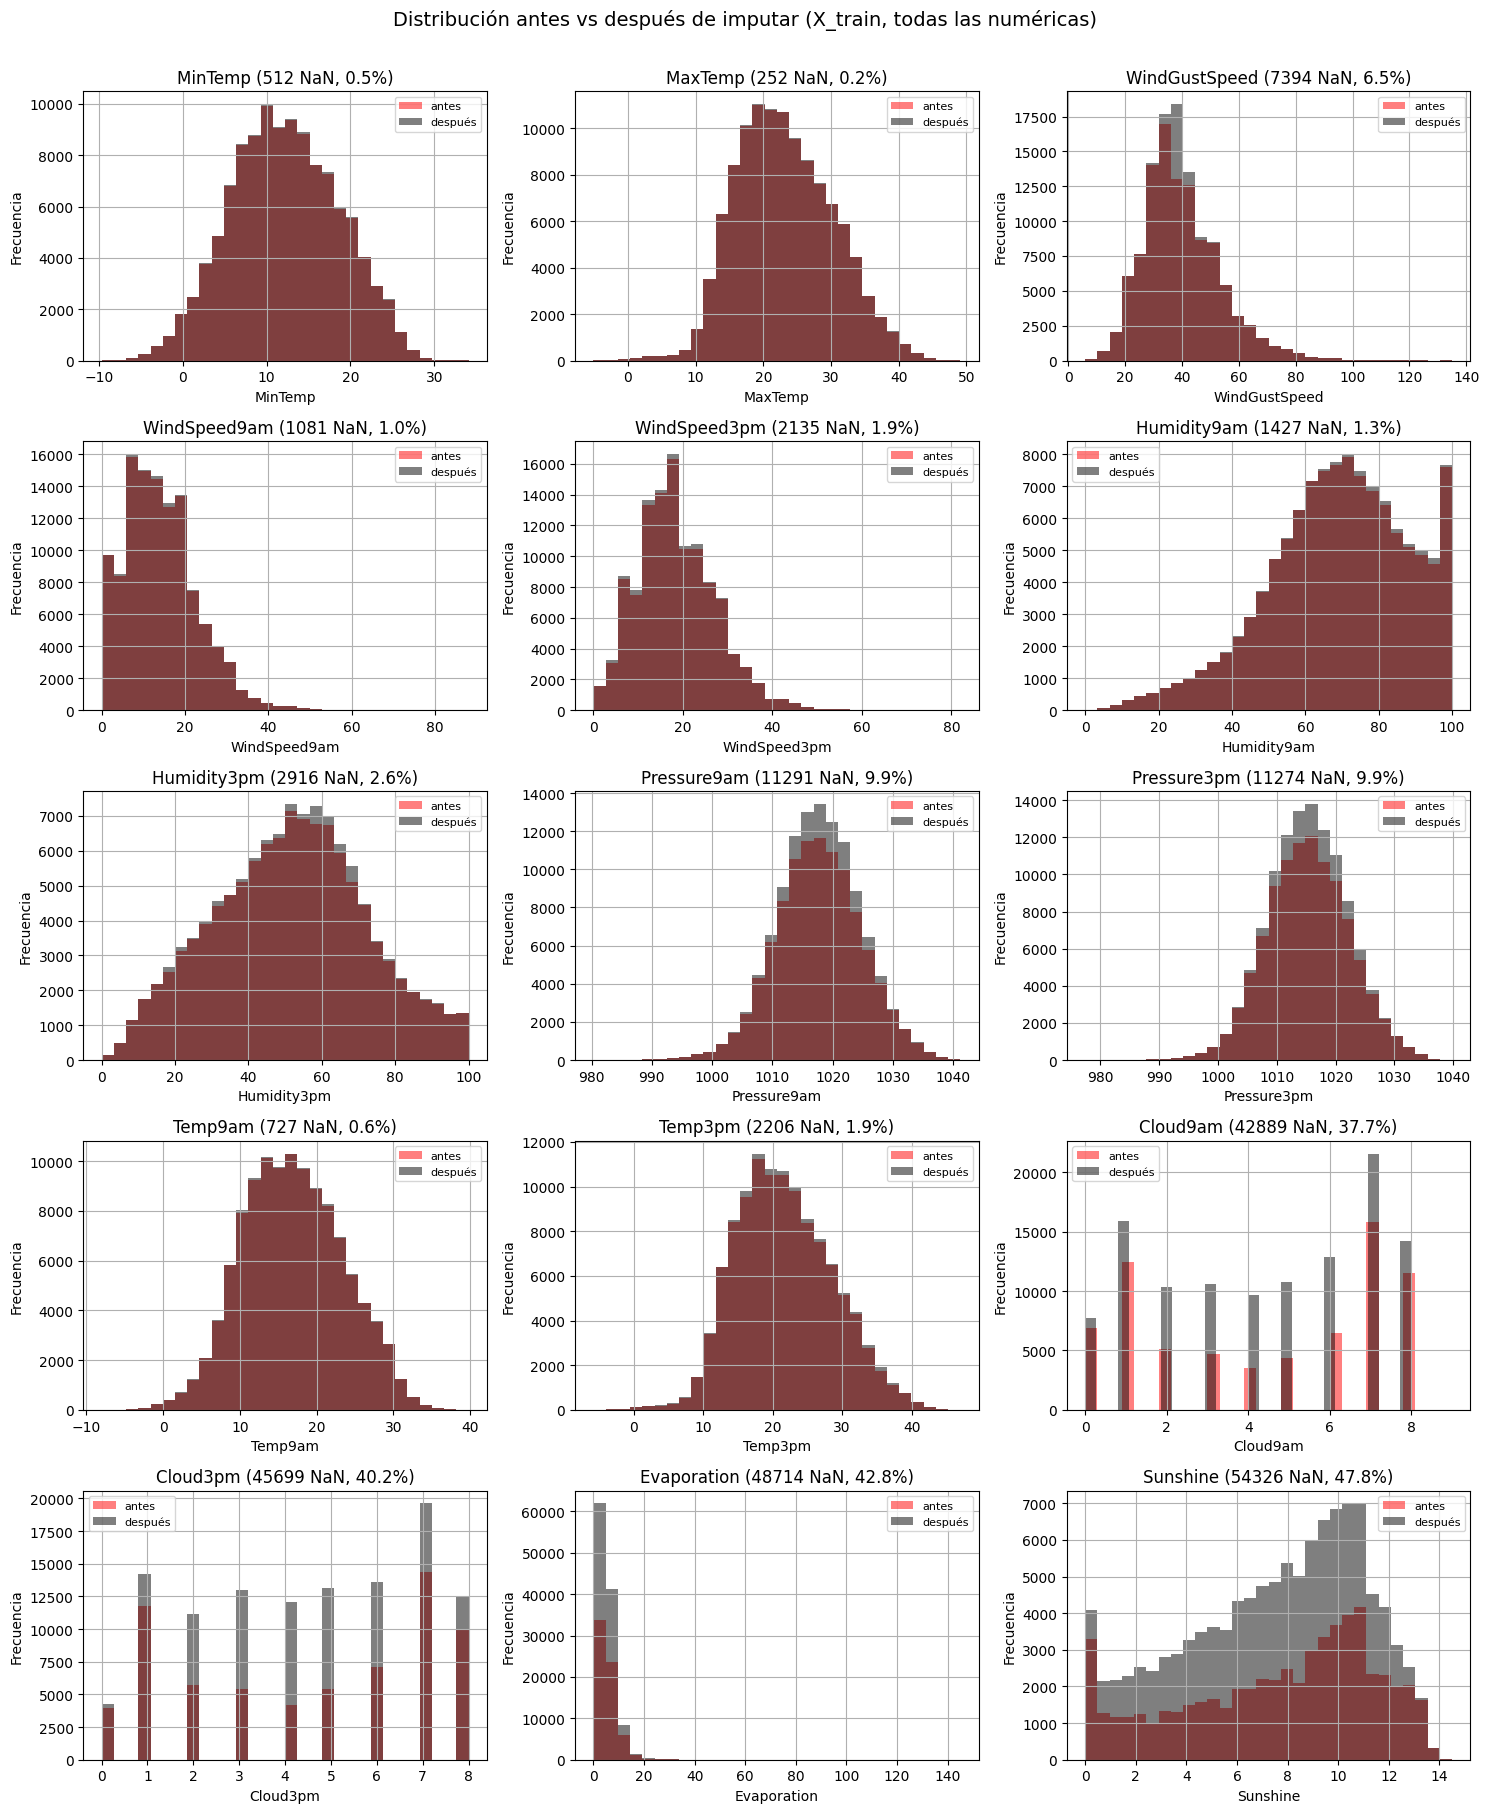

In [25]:
# Comparamos distribuciones antes vs después de imputar (X_train)
# para todas las variables numéricas que pasaron por la cascada
vars_num = ['MinTemp', 'MaxTemp', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
            'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
            'Temp9am', 'Temp3pm', 'Cloud9am', 'Cloud3pm', 'Evaporation', 'Sunshine']

fig, axes = plt.subplots(5, 3, figsize=(15, 18))

for i, c in enumerate(vars_num):
  ax = axes[i // 3, i % 3]
  X_train[c].dropna().hist(ax=ax, bins=30, alpha=0.5, color='red', label='antes')
  X1_train[c].hist(ax=ax, bins=30, alpha=0.5, color='black', label='después')
  n_imp = X_train[c].isna().sum()
  pct = round(100 * n_imp / len(X_train), 1)
  ax.set_title(f'{c} ({n_imp} NaN, {pct}%)')
  ax.set_xlabel(c)
  ax.set_ylabel('Frecuencia')
  ax.legend(fontsize=8)

plt.suptitle('Distribución antes vs después de imputar (X_train, todas las numéricas)', fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

Se observa que el proceso de imputación preservó con gran fidelidad la estructura y el sesgo de la mayoría de las variables con bajos porcentajes de datos faltantes. Sin embargo, en las variables con alta tasa de nulos (Evaporation, Sunshine, Cloud9am y Cloud3pm), el uso de KNNImputer (con k=5) introdujo distorsiones visuales específicas:
* Concentración en extremos: En Evaporation se sobreestimó drásticamente la frecuencia en valores cercanos a cero debido a la fuerte asimetría original de la variable.
* Efecto del redondeo: En Cloud9am y Cloud3pm, el proceso de redondeo posterior a la imputación continua de KNN concentró artificialmente los datos en los niveles más altos (especialmente 7 y 8 octas).
* Suavizado de Sunshine: Se conservó la tendencia general bimodal, pero con un incremento notable de frecuencias en los días de alta radiación solar (valores cercanos a 11).

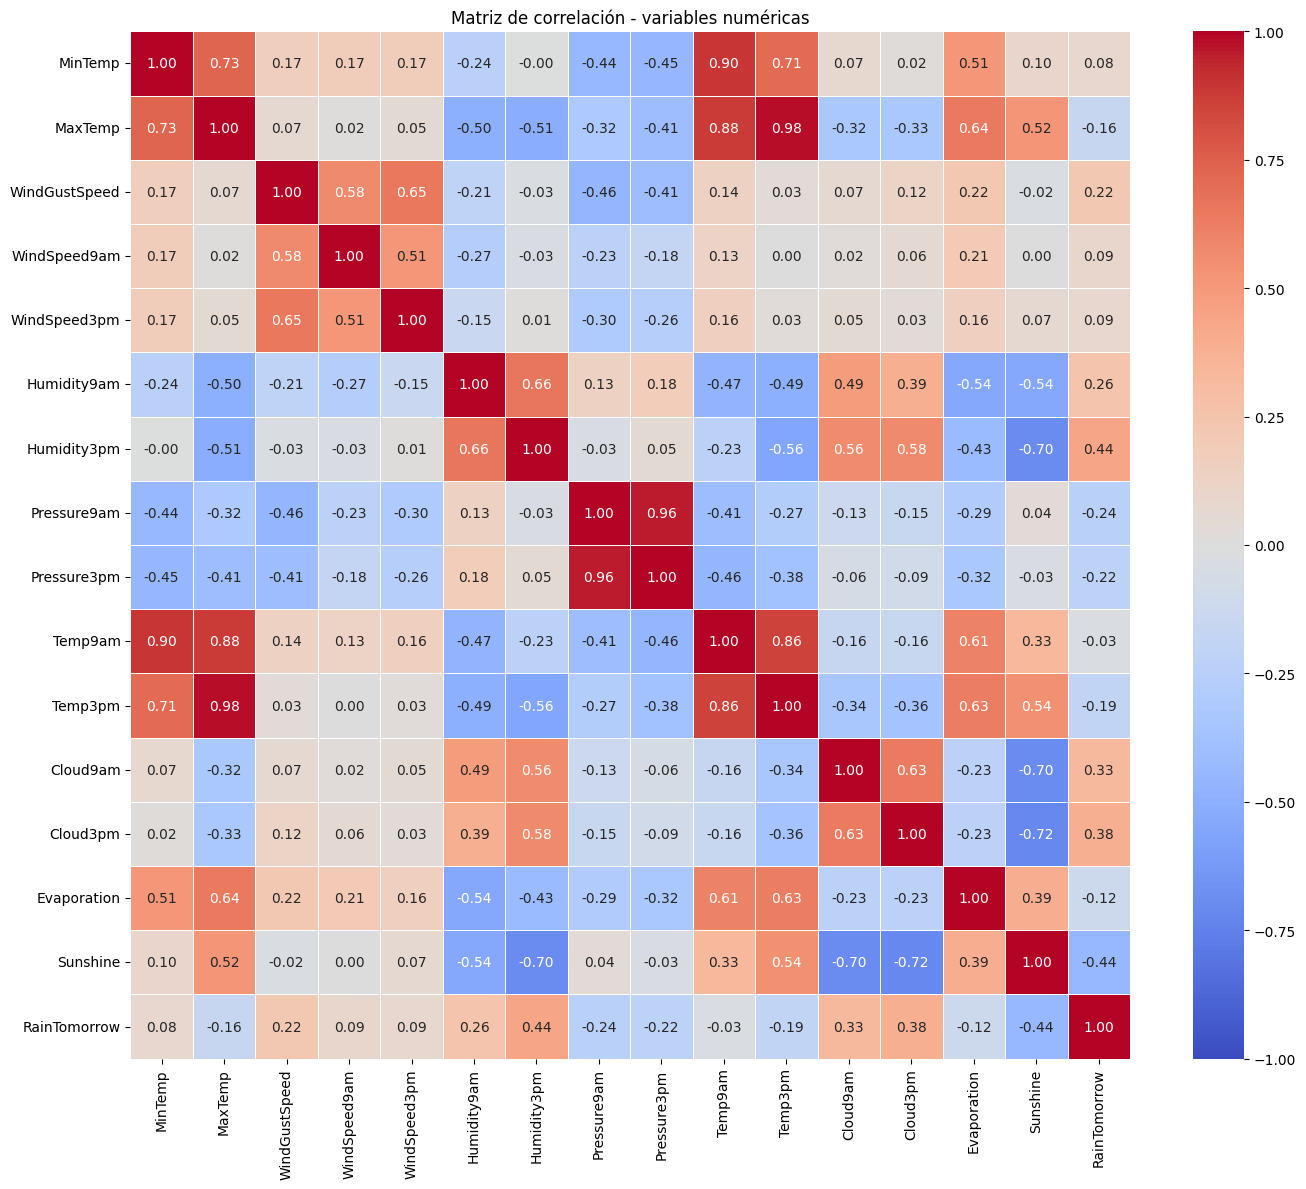

In [26]:
# Matriz de correlación
data_corr = pd.concat([X1_train[vars_num], y_train], axis=1)

corr1 = data_corr.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr1, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, center=0, vmin=-1, vmax=1)

plt.title('Matriz de correlación - variables numéricas')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

La correlación de las variables Cloud9am, Cloud3pm, Evaporation y Sunshine aumentó levemente respecto al análisis preliminar; esto es una consecuencia directa de la imputación mediante KNN.

Con respecto a la variable objetivo (RainTomorrow), la humedad de la tarde (Humidity3pm) presenta el impacto lineal positivo más fuerte (0.44), seguida muy de cerca por la cobertura nubosa de la tarde (Cloud3pm con 0.38) y de la mañana (Cloud9am con 0.33), lo que indica que las condiciones húmedas y nubladas incrementan notablemente la probabilidad de lluvia al día siguiente. En sentido contrario, las horas de sol (Sunshine) muestran la relación inversa más marcada (-0.44), asociando de forma clara los días despejados a una menor probabilidad de precipitación, mientras que las velocidades del viento aportan una influencia positiva moderada (0.22) y el resto de las variables climáticas registran correlaciones lineales directas muy bajas con el objetivo.

## Tratamiento de Variables con Distribuciones Binomiales o Sesgadas

In [27]:
# 1. Feature Engineering: Viento Extremo y Winsorization
# Definimos las variables de viento a tratar
cols_viento = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']

for c in cols_viento:
  # 1. Calculamos el percentil 99 SOLO con el X_train
  umbral_99 = X1_train[c].quantile(0.99)
  
  # 2. Creamos la nueva variable flag (1 si es extremo, 0 si no)
  nombre_flag = c + '_Extreme'
  X1_train[nombre_flag] = (X1_train[c] > umbral_99).astype(int)
  X1_test[nombre_flag] = (X1_test[c] > umbral_99).astype(int)
  
  # 3. Aplicamos Winsorization (Recorte / Capping)
  X1_train[c] = np.clip(X1_train[c], a_min=None, a_max=umbral_99)
  X1_test[c] = np.clip(X1_test[c], a_min=None, a_max=umbral_99)

In [28]:
# 2. Feature Engineering: Lluvia Extrema y Transformación Logarítmica
# Usamos percentil 99 para marcar aguaceros severos
# 1. Flag de Lluvia Extrema (Usando el percentil 99 del Train)
umbral_lluvia_extrema = X1_train['Rainfall'].quantile(0.99)

X1_train['Rainfall_Extreme'] = (X1_train['Rainfall'] > umbral_lluvia_extrema).astype(int)
X1_test['Rainfall_Extreme'] = (X1_test['Rainfall'] > umbral_lluvia_extrema).astype(int)

# 2. Transformación Logarítmica para aplastar la asimetría
# Usamos log1p (log(x + 1)) porque hay muchos días con 0 lluvia, y log(0) da error.
X1_train['Rainfall'] = np.log1p(X1_train['Rainfall'])
X1_test['Rainfall'] = np.log1p(X1_test['Rainfall'])

X1_train['Evaporation'] = np.log1p(X1_train['Evaporation'])
X1_test['Evaporation'] = np.log1p(X1_test['Evaporation'])

In [29]:
# 3. Feature Engineering: Variables Delta (Diferencias Diarias)
# Restamos la tarde menos la mañana para capturar la tendencia
for X in [X1_train, X1_test]:
  X['Delta_Pressure'] = X['Pressure3pm'] - X['Pressure9am']
  X['Delta_Humidity'] = X['Humidity3pm'] - X['Humidity9am']
  X['Delta_Temp'] = X['Temp3pm'] - X['Temp9am']

## Escalado de Datos

In [30]:
# 1. Identificamos las columnas de texto originales que ya no necesitamos 
# porque ya calculaste sus versiones dummificadas (dummies) previamente.
cols_objeto_originales = ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

# Creamos vistas temporales filtradas SOLO para el proceso de escalado,
# dejando fuera el texto que confunde al passthrough.
X_train_temp = X1_train.drop(columns=cols_objeto_originales, errors='ignore')
X_test_temp = X1_test.drop(columns=cols_objeto_originales, errors='ignore')

# 2. Variables a escalar (se mantiene tu lógica intacta)
cols_minmax = ['Humidity9am', 'Humidity3pm', 'Cloud9am', 'Cloud3pm', 'Sunshine']
cols_standard = [
    'MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm',
    'Pressure9am', 'Pressure3pm',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 
    'Rainfall', 'Evaporation',         
    'Delta_Pressure', 'Delta_Humidity', 'Delta_Temp' 
]

# 3. Configuramos el ColumnTransformer sobre los datos temporales limpios
preprocessor = ColumnTransformer(
    transformers=[
        ('minmax', MinMaxScaler(), cols_minmax),
        ('standard', StandardScaler(), cols_standard)
    ],
    remainder='passthrough' 
)

# 4. Aplicamos el escalado
X_train_escalado_array = preprocessor.fit_transform(X_train_temp)
X_test_escalado_array = preprocessor.transform(X_test_temp)

# 5. Reconstrucción con reasignación sobre tus variables originales (X1_train / X1_test)
# Ahora 'columnas_remainder' solo contendrá las variables dummificadas y cíclicas (numéricas)
columnas_remainder = [c for c in X_train_temp.columns if c not in cols_minmax + cols_standard]
nombres_finales = cols_minmax + cols_standard + columnas_remainder

# Sobreescribimos tus variables. El .astype('float32') al final unifica la precisión
# de los booleanos de las dummies y los flotantes del escalado de forma segura y homogénea.
X1_train = pd.DataFrame(
    X_train_escalado_array, 
    columns=nombres_finales, 
    index=X1_train.index
).astype('float32')

X1_test = pd.DataFrame(
    X_test_escalado_array, 
    columns=nombres_finales, 
    index=X1_test.index
).astype('float32')

# Verificación de control profesional
print("¡Escalado completado con éxito!")
print(f"Dimensiones finales Train (100% numérico puro): {X1_train.shape}")
print(f"¿Quedan columnas tipo 'object'?: {any(X1_train.dtypes == 'object')}")

¡Escalado completado con éxito!
Dimensiones finales Train (100% numérico puro): (113722, 83)
¿Quedan columnas tipo 'object'?: False


## Distribución de los Datos Despues del Escalado

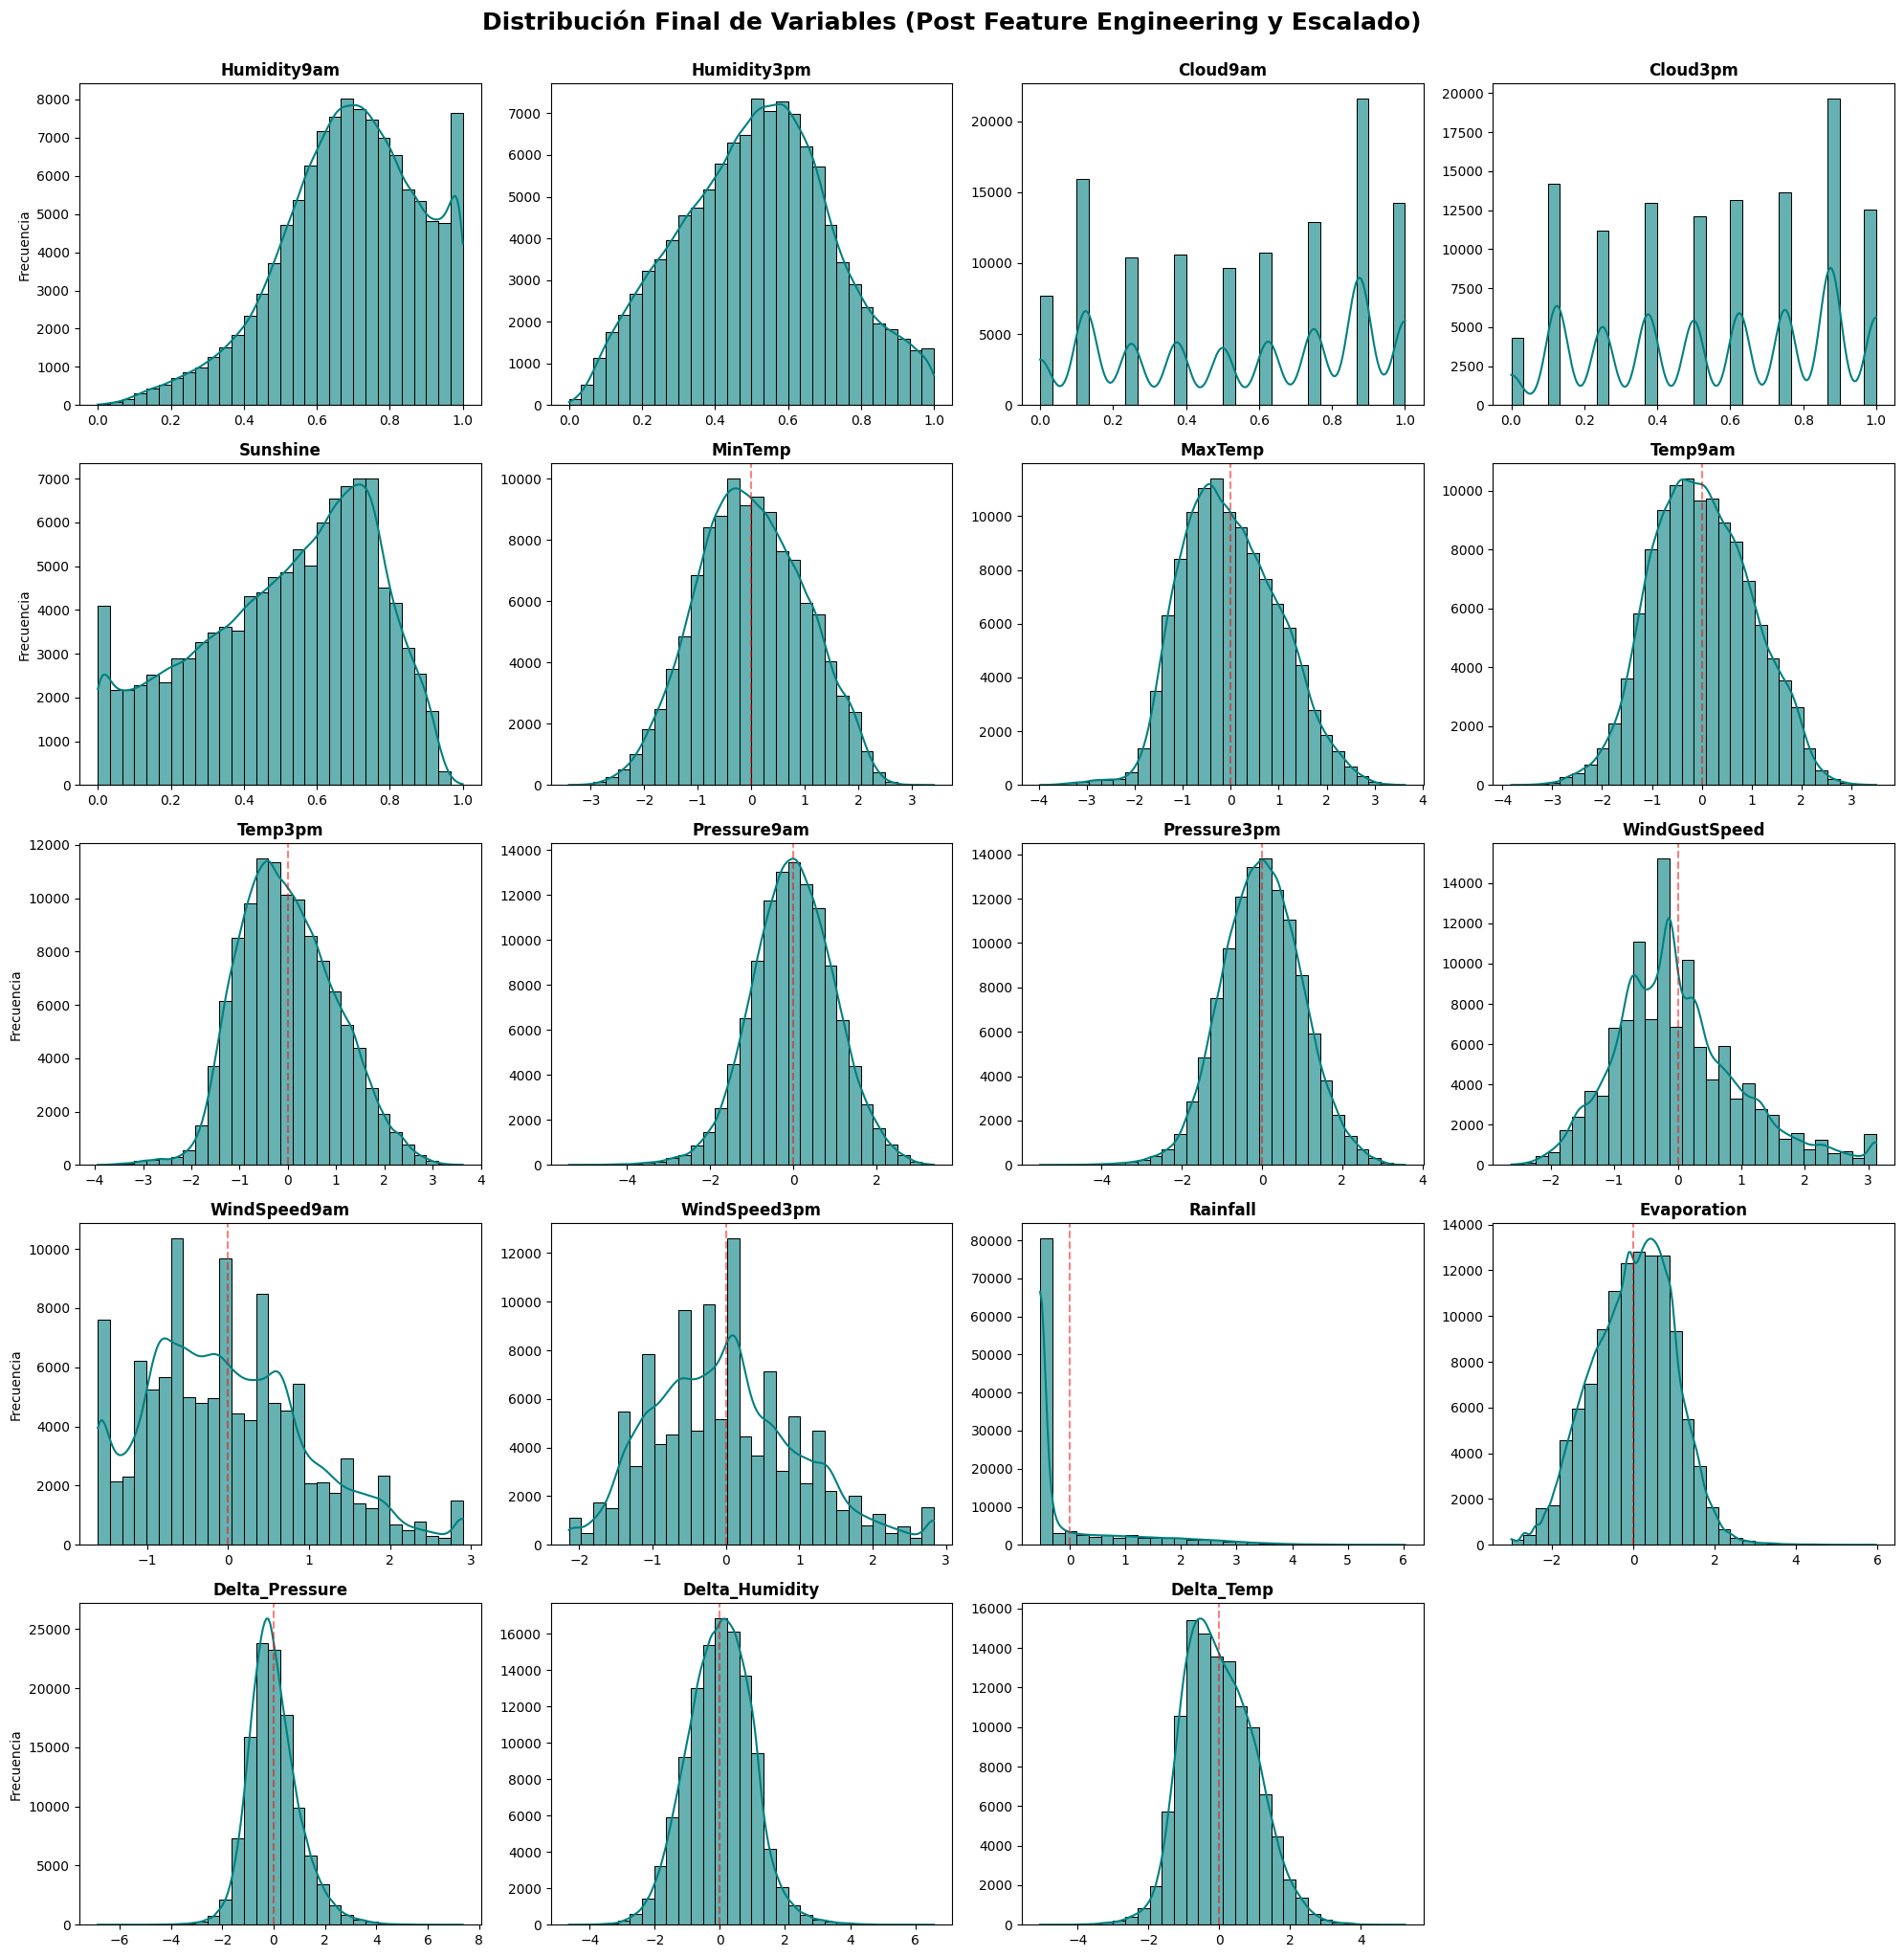

In [31]:
# 1. Seleccionamos las columnas que nos interesa ver (las que pasaron por los escaladores)
variables_a_graficar = cols_minmax + cols_standard

# 2. Configuramos la grilla dinámica (4 gráficos por fila)
num_vars = len(variables_a_graficar)
filas = (num_vars // 4) + (1 if num_vars % 4 != 0 else 0)

fig, axes = plt.subplots(filas, 4, figsize=(20, 4 * filas))
axes = axes.flatten()

# 3. Dibujamos cada histograma
for i, col in enumerate(variables_a_graficar):
  # Usamos un color distinto para diferenciar visualmente esta etapa
  sns.histplot(data=X1_train, x=col, bins=30, kde=True, ax=axes[i], color='teal', alpha=0.6)
  
  axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Frecuencia' if i % 4 == 0 else '')
  
  # Agregamos una línea vertical punteada en el 0 para las variables Standard
  if col in cols_standard:
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)

# 4. Limpiamos los ejes vacíos si la cantidad de variables no es múltiplo de 4
for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribución Final de Variables (Post Feature Engineering y Escalado)', y=1.02, fontsize=18, fontweight='bold')
plt.show()

El gráfico de distribuciones finales muestra el impacto del preprocesamiento y el escalado sobre el conjunto de datos, destacando que las variables de temperatura, presión y las nuevas diferencias calculadas (Delta_Pressure, Delta_Humidity y Delta_Temp) lograron adoptar formas aproximadamente simétricas y gaussianas centradas en cero, mientras que características inherentemente sesgadas como Rainfall y Evaporation retuvieron su asimetría original reflejando la naturaleza real de los eventos climáticos extremos; por otra parte, variables como Sunshine y las humedades exhiben comportamientos no normales bien definidos, y las nubes junto a las velocidades del viento (WindSpeed9am y WindSpeed3pm) muestran distribuciones multimodales o discretizadas con picos marcados derivados de los procesos previos de imputación por vecinos y redondeo en sus escalas normalizadas.

# 2 — Regresión Logística

## Entrenamiento de Modelos
Entrenamos dos modelos cruzando dos ejes:
- **Dataset**: clima1
- **Pesos de clase**: baseline (default) vs class_weight='balanced' para mitigar el desbalance 77/22

In [32]:
# 2 modelos: (clima1: baseline, balanced)
lr_c1_base = LogisticRegression(random_state=42, max_iter=1000)
lr_c1_bal  = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Entrenar cada uno sobre su respectivo train
lr_c1_base.fit(X1_train, y_train)
lr_c1_bal.fit(X1_train,  y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you migh

In [33]:
print('clima1 baseline | nº de coeficientes:', len(lr_c1_base.coef_[0]))

clima1 baseline | nº de coeficientes: 83


Entrenamos dos modelos: uno para dataset (clima1) y otro para peso de clase (balanced). El class_weight='balanced' reescalas los pesos según n_samples / (n_classes * n_samples_clase), lo que penaliza más fuerte los errores en la clase Yes (22% del dataset). En el siguiente paso comparamos las métricas para decidir qué combinación funciona mejor.

In [34]:
# Predicciones sobre test para cada modelo
# Primero se debe asegurar que X1_test tenga las mismas columnas que X1_train_final
X1_test_final = X1_test.reindex(columns=X1_train.columns, fill_value=0)

y_pred_c1_base = lr_c1_base.predict(X1_test_final)
y_pred_c1_bal  = lr_c1_bal.predict(X1_test_final)

Elegimos como metrica adicional MCC. Esto nos permite ver que tan correlacionadas estan las predicciones del modelo con las etiquetas reales, ademas es una metrica robusta contra el desbalance.

In [35]:
# Función auxiliar
def metricas(y_true, y_pred, nombre):
  return {
    'modelo': nombre,
    'accuracy': accuracy_score(y_true, y_pred),
    'precision_yes': precision_score(y_true, y_pred, pos_label=1),
    'recall_yes': recall_score(y_true, y_pred, pos_label=1),
    'f1_yes': f1_score(y_true, y_pred, pos_label=1),
    'mcc': matthews_corrcoef(y_true, y_pred),
  }

resumen = pd.DataFrame([metricas(y_test, y_pred_c1_base, 'lr_c1_base'), metricas(y_test, y_pred_c1_bal,  'lr_c1_bal')])

resumen.round(4)

,modelo,accuracy,precision_yes,recall_yes,f1_yes,mcc
0,lr_c1_base,0.8458,0.7168,0.5158,0.5999,0.5181
1,lr_c1_bal,0.7910,0.5230,0.7733,0.6240,0.5045


**Metricas**:

* accuracy: aciertos totales / total
* precision_yes: De los que predijo Yes, cuantos fueron Yes realmente
* recall_yes: de los Yes reales, cuantos detecto
* f1_yes: media armonica de precision_yes y recall_yes
* mcc: correlacion de Pearson entre prediccion y target. es robusta al desbalance, metrica global que considera los 4 cuadrantes. Muestra la calidad general de prediccion y como para los 2 modelos se mantiene con valores cercanos a 0.5 la calidad general de prediccion es parecida, lo que cambia es donde acepta equivocarse el modelo(FN vs FP)

In [36]:
# Queremos confirmar que balanceando no solo se mejora recall en "Yes", sino que tambien podemos ver que pasa con "No"
modelos = [('lr_c1_base', lr_c1_base, X1_test), ('lr_c1_bal',  lr_c1_bal,  X1_test)]

for nombre, modelo, X_test_local in modelos:
  print(nombre)
  print(classification_report(y_test, modelo.predict(X_test_local), target_names=['No', 'Yes']))

lr_c1_base
              precision    recall  f1-score   support

          No       0.87      0.94      0.90     22057
         Yes       0.72      0.52      0.60      6374

    accuracy                           0.85     28431
   macro avg       0.79      0.73      0.75     28431
weighted avg       0.84      0.85      0.84     28431

lr_c1_bal
              precision    recall  f1-score   support

          No       0.92      0.80      0.86     22057
         Yes       0.52      0.77      0.62      6374

    accuracy                           0.79     28431
   macro avg       0.72      0.78      0.74     28431
weighted avg       0.83      0.79      0.80     28431



Elegimos MCC porque está diseñado para clasificación binaria desbalanceada, que es nuestro caso (77/22). A diferencia de accuracy, MCC no se deja llevar por una clase dominante: un modelo que siempre predice 'No' saca accuracy de 77% pero MCC de 0 y esto es exactamente a lo que queremos estar cubiertos

**Conclusion sobre los modelos:**

* La accuracy engaña por el desbalance 77/22. Miramos recall_yes y f1_yes.

* class_weight='balanced' cambia precision por recall: detecta el 77% de los
  dias lluviosos en vez del 50%, pero precision_yes baja de 0.71 a 0.52. f1_yes
  mejora levemente (0.58 → 0.62).

* MCC se mantiene en ~0.50 en los 4: calidad general parecida, lo que cambia
  es donde acepta equivocarse el modelo. Como en este problema un FN (sin
  paraguas) es mas costoso que un FP (paraguas por las dudas), preferimos el _bal.

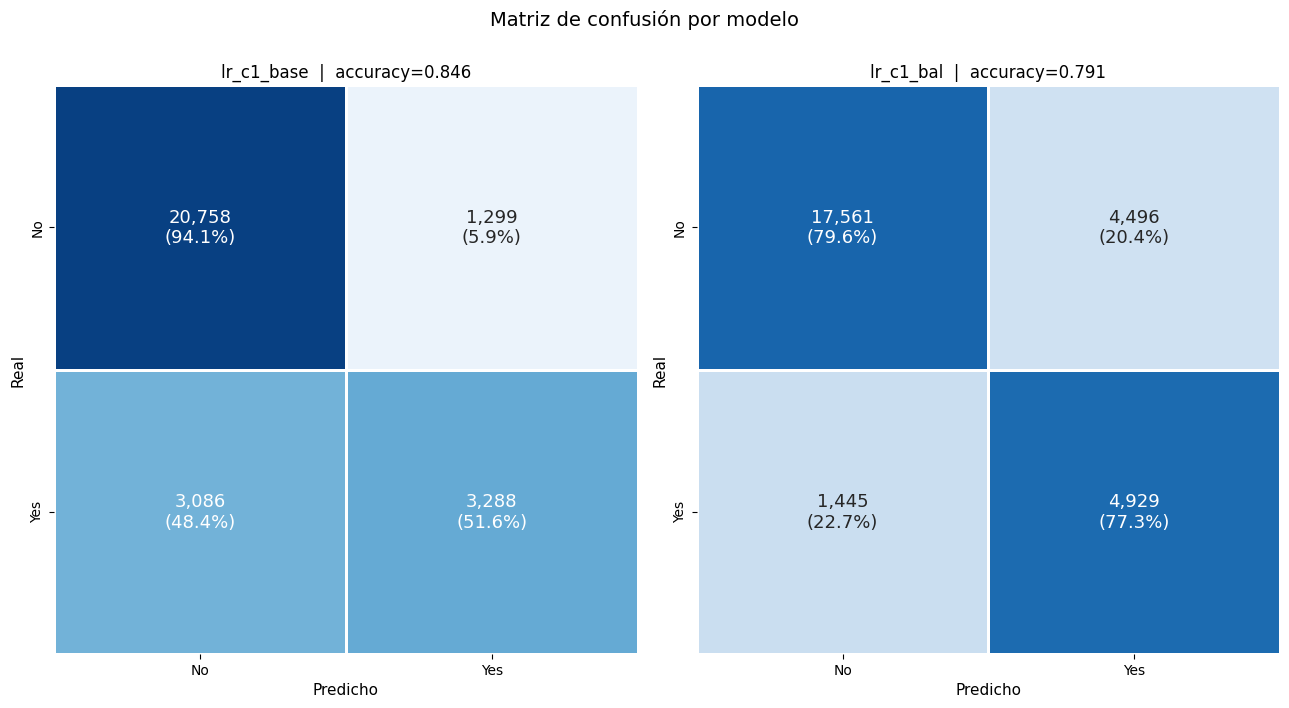

In [37]:
modelos_conf = [('lr_c1_base', y_pred_c1_base), ('lr_c1_bal',  y_pred_c1_bal)]

fig, axes = plt.subplots(1, 2, figsize=(13, 7))

for i, (nombre, y_pred) in enumerate(modelos_conf):
  ax = axes[i]
  cm = confusion_matrix(y_test, y_pred)
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

  annot = np.array([[f'{cm[r, c]:,}\n({cm_norm[r, c]*100:.1f}%)' for c in range(2)] for r in range(2)])

  sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues',
    xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
    ax=ax, cbar=False, vmin=0, vmax=1,
    annot_kws={'size': 13},
    linewidths=1, linecolor='white')

  acc = (cm[0, 0] + cm[1, 1]) / cm.sum()
  ax.set_xlabel('Predicho', fontsize=11)
  ax.set_ylabel('Real', fontsize=11)
  ax.set_title(f'{nombre}  |  accuracy={acc:.3f}', fontsize=12)

plt.suptitle('Matriz de confusión por modelo', fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

**Analisis de FN y FP**
* ¿Que quiere decir cada uno?

* Falso Negativo (FN): el modelo predijo que "no llovia" pero al dia siguiente si llovio

* Falso Positivo (FP): el modelo predijo "lluvia" pero al dia siguiente no llovio

En este problema un FN es mas costoso que un FP. Salir sin paraguas y mojarse es peor que llevar un paraguas por las dudas

Esta es la justificacion de priorizar modelos con mas recall_yes (menos FN), aunque pueda implicar mas FP

## Curva ROC + AUC

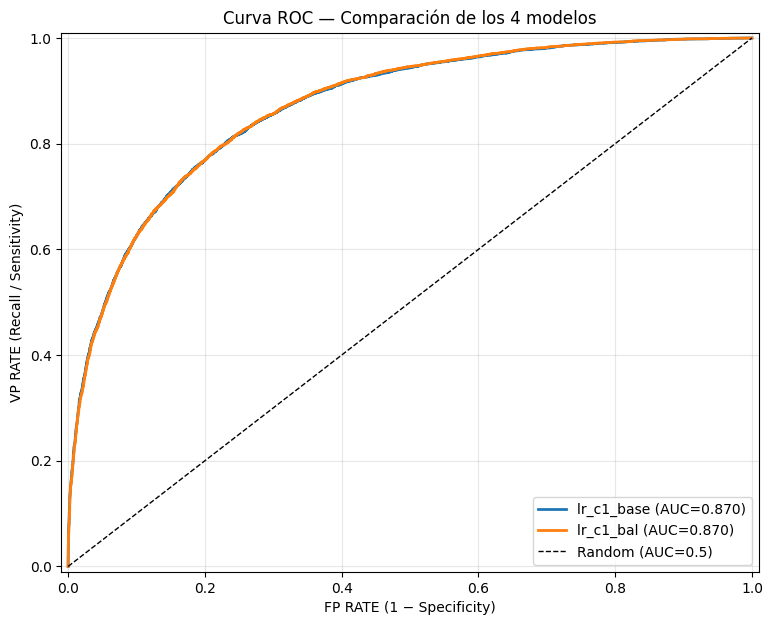

In [38]:
modelos_roc = [('lr_c1_base', lr_c1_base, X1_test), ('lr_c1_bal',  lr_c1_bal,  X1_test)]

plt.figure(figsize=(9, 7))

for nombre, modelo, X_t in modelos_roc:
  y_score = modelo.predict_proba(X_t)[:, 1]   # Probabilidad de la clase positiva (Yes)
  fpr, tpr, _ = roc_curve(y_test, y_score)
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label=f'{nombre} (AUC={roc_auc:.3f})', linewidth=2)

# Línea de referencia: clasificador aleatorio
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('FP RATE (1 − Specificity)')
plt.ylabel('VP RATE (Recall / Sensitivity)')
plt.title('Curva ROC — Comparación de los 4 modelos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Las 2 curvas quedan casi superpuestas con AUC ~0.86. Esto es debido a que el class_weight='balanced' no toca el ranking de probabilidades que arma el modelo, solo el umbral implicito para decidir. Como ROC barre todos los umbrales, ve la calidad global y no cambia.


In [39]:
modelos_youden = [('lr_c1_base', lr_c1_base, X1_test), ('lr_c1_bal',  lr_c1_bal,  X1_test)]

filas = []
for nombre, modelo, X_t in modelos_youden:
  y_score = modelo.predict_proba(X_t)[:, 1]
  fpr, tpr, thresholds = roc_curve(y_test, y_score)

  # Youden's J = TPR - FPR, queremos el máximo
  youden_idx = (tpr - fpr).argmax()
  umbral_y = thresholds[youden_idx]

  # Predicciones a cada umbral
  y_pred_05 = (y_score >= 0.5).astype(int)
  y_pred_y  = (y_score >= umbral_y).astype(int)

  filas.append({
    'modelo':       nombre,
    'umbral_y':     round(umbral_y, 3),
    'acc_0.5':      round(accuracy_score(y_test, y_pred_05), 3),
    'rec_yes_0.5':  round(recall_score(y_test, y_pred_05, pos_label=1), 3),
    'prec_yes_0.5': round(precision_score(y_test, y_pred_05, pos_label=1), 3),
    'f1_yes_0.5':   round(f1_score(y_test, y_pred_05, pos_label=1), 3),
    'acc_y':        round(accuracy_score(y_test, y_pred_y), 3),
    'rec_yes_y':    round(recall_score(y_test, y_pred_y, pos_label=1), 3),
    'prec_yes_y':   round(precision_score(y_test, y_pred_y, pos_label=1), 3),
    'f1_yes_y':     round(f1_score(y_test, y_pred_y, pos_label=1), 3),
  })

comparacion_umbrales = pd.DataFrame(filas)
comparacion_umbrales

,modelo,umbral_y,acc_0.5,rec_yes_0.5,prec_yes_0.5,f1_yes_0.5,acc_y,rec_yes_y,prec_yes_y,f1_yes_y
0,lr_c1_base,0.197,0.846,0.516,0.717,0.600,0.776,0.805,0.500,0.617
1,lr_c1_bal,0.486,0.791,0.773,0.523,0.624,0.787,0.785,0.516,0.623


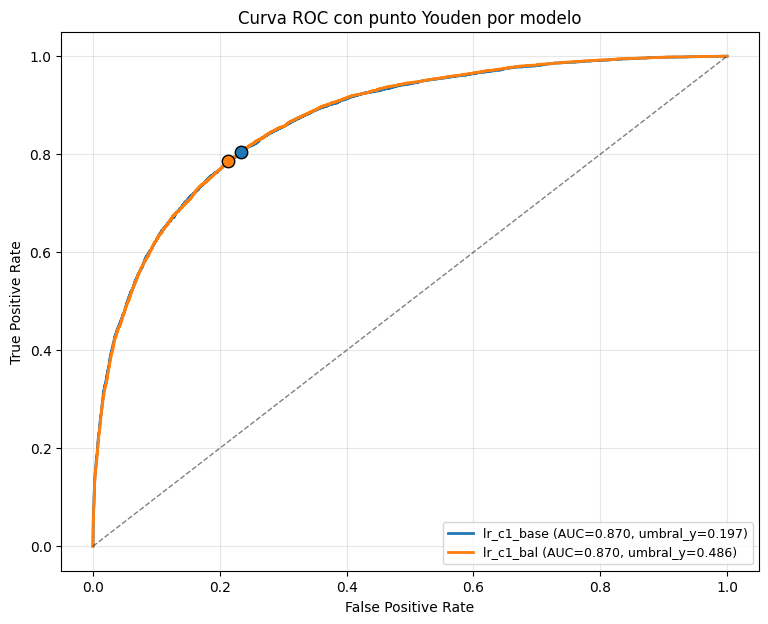

In [40]:
plt.figure(figsize=(9, 7))

for nombre, modelo, X_t in modelos_youden:
  y_score = modelo.predict_proba(X_t)[:, 1]
  fpr, tpr, thresholds = roc_curve(y_test, y_score)
  roc_auc_val = auc(fpr, tpr)

  youden_idx = (tpr - fpr).argmax()

  plt.plot(fpr, tpr, label=f'{nombre} (AUC={roc_auc_val:.3f}, umbral_y={thresholds[youden_idx]:.3f})', linewidth=2)
  plt.scatter(fpr[youden_idx], tpr[youden_idx], s=80, zorder=5, edgecolor='black')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC con punto Youden por modelo')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.show()

**Umbral optimo con Youden:**

Youden busca el umbral que maximiza TPR - FPR. Lo aplicamos a los 4 modelos.

El baseline da umbral optimo entre 0.21, bastante lejos de 0.5. Es
porque esta sesgado a predecir "No" por el desbalance. El balanced en
cambio dan umbral cerca de 0.5, lo que confirma que el class_weight='balanced'
ya hace internamente lo que Youden haria desde afuera.

**¿Es 0.5 el mejor?**

Para el baseline no, conviene bajarlo. Para el balanced
si, ya está cerca del optimo. La eleccion final del umbral igual depende del
costo relativo entre FN y FP en el problema.

**¿Como calcular el mejor umbral?**

* Youden's J (el que usamos): maximiza TPR - FPR. Estandar para curvas ROC
* Maximizar F1: balance entre precision y recall
* Maximizar balanced accuracy: promedio de recall entre las dos clases
* Minimo costo esperado: si los FN y FP tienen costos distintos en el
  problema, se pondera y se busca el umbral que minimiza el costo total

## Analisis de Fitting

In [41]:
modelos_fit = [('lr_c1_base', lr_c1_base, X1_train, X1_test_final), ('lr_c1_bal',  lr_c1_bal,  X1_train, X1_test_final)]

filas = []
for nombre, modelo, X_tr, X_te in modelos_fit:
  y_pred_tr = modelo.predict(X_tr)
  y_pred_te = modelo.predict(X_te)

  acc_tr  = accuracy_score(y_train, y_pred_tr)
  acc_te  = accuracy_score(y_test,  y_pred_te)
  f1_tr   = f1_score(y_train, y_pred_tr, pos_label=1)
  f1_te   = f1_score(y_test,  y_pred_te, pos_label=1)
  rec_tr  = recall_score(y_train, y_pred_tr, pos_label=1)
  rec_te  = recall_score(y_test,  y_pred_te, pos_label=1)

  filas.append({
    'modelo':       nombre,
    'acc_train':    round(acc_tr, 4),
    'acc_test':     round(acc_te, 4),
    'acc_gap':      round(acc_tr - acc_te, 4),
    'f1_yes_train': round(f1_tr, 4),
    'f1_yes_test':  round(f1_te, 4),
    'f1_yes_gap':   round(f1_tr - f1_te, 4),
    'rec_yes_train':round(rec_tr, 4),
    'rec_yes_test': round(rec_te, 4),
    'rec_yes_gap':  round(rec_tr - rec_te, 4),
  })

fitting_df = pd.DataFrame(filas)
fitting_df

,modelo,acc_train,acc_test,acc_gap,f1_yes_train,f1_yes_test,f1_yes_gap,rec_yes_train,rec_yes_test,rec_yes_gap
0,lr_c1_base,0.8462,0.8458,0.0004,0.5991,0.5999,-0.0009,0.5126,0.5158,-0.0033
1,lr_c1_bal,0.7911,0.7910,0.0000,0.6257,0.6240,0.0018,0.7789,0.7733,0.0056


**Fitting train vs test:**

Las diferencias entre train y test son <0.01 en todas las metricas. No hay
overfitting — la regresion logistica con L2 y 113k filas generaliza bien.


# 3 — Modelo Base Alternativo 

## Decision Tree

Como segundo clasificador elegimos Decision Tree. La idea es contrastar el
modelo lineal del item 2 contra uno no lineal y ver si hay relaciones que la
regresion logistica no estaba capturando.

Usamos Decision Tree porque puede capturar relaciones no lineales entre variables y además permite interpretar fácilmente qué decisiones toma el modelo. También probamos distintos hiperparámetros con GridSearch para optimizar el rendimiento.

En este punto entrenamos un Decision Tree baseline, evaluamos sus métricas y luego optimizamos hiperparámetros con GridSearchCV. Finalmente, comparamos el mejor árbol obtenido contra el mejor modelo de regresión logística.

In [42]:
# Decision Tree baseline sobre clima1 con parametros default
dt_c1_base = DecisionTreeClassifier(random_state=42)
dt_c1_base.fit(X1_train, y_train)

# Predicciones (clases y probabilidades)
y_pred_dt = dt_c1_base.predict(X1_test)
y_score_dt = dt_c1_base.predict_proba(X1_test)[:, 1]

print('Profundidad del arbol:', dt_c1_base.get_depth())
print('Hojas:', dt_c1_base.get_n_leaves())

Profundidad del arbol: 35
Hojas: 12140


In [43]:
print('Decision Tree baseline (clima1) — métricas en TEST:')
print(f'  accuracy:      {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'  precision_yes: {precision_score(y_test, y_pred_dt, pos_label=1):.4f}')
print(f'  recall_yes:    {recall_score(y_test, y_pred_dt, pos_label=1):.4f}')
print(f'  f1_yes:        {f1_score(y_test, y_pred_dt, pos_label=1):.4f}')
print(f'  mcc:           {matthews_corrcoef(y_test, y_pred_dt):.4f}')

# También en TRAIN para ver overfitting
y_pred_dt_train = dt_c1_base.predict(X1_train)
print('\nDecision Tree baseline — métricas en TRAIN:')
print(f'  accuracy: {accuracy_score(y_train, y_pred_dt_train):.4f}')
print(f'  f1_yes:   {f1_score(y_train, y_pred_dt_train, pos_label=1):.4f}')

Decision Tree baseline (clima1) — métricas en TEST:
  accuracy:      0.7853
  precision_yes: 0.5205
  recall_yes:    0.5372
  f1_yes:        0.5287
  mcc:           0.3898

Decision Tree baseline — métricas en TRAIN:
  accuracy: 1.0000
  f1_yes:   0.9999


El Decision Tree baseline presentó overfitting: obtuvo métricas muy altas en train, pero bajó en test. Además, rindió peor que la regresión logística, por lo que usamos GridSearchCV para limitar la complejidad del árbol y mejorar la generalización.


# 4 — Optimización de Hiperparámetros 

Incluye:
* Validación cruzada k-folds
* Grid Search
* Random Search
* Optuna

In [ ]:
# StratifiedKFold mantiene la proporción de clases en cada fold,
# algo importante cuando el target está desbalanceado.
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Espacio de búsqueda de hiperparámetros
param_grid = {
  'max_depth': [5, 10, 15],
  'min_samples_leaf': [10, 20, 50],
  'criterion': ['gini', 'entropy'],
  'class_weight': [None, 'balanced'],
  'max_features': [None, 'sqrt']
}

grid_search = GridSearchCV(
  estimator=DecisionTreeClassifier(random_state=42),
  param_grid=param_grid,
  cv=cv_strat,
  scoring='f1',
  n_jobs=-1,
  verbose=1
)

random_search = RandomizedSearchCV(
  estimator=DecisionTreeClassifier(random_state=42),
  param_distributions=param_grid,
  n_iter=25,
  cv=cv_strat,
  scoring='f1',
  n_jobs=-1,
  random_state=42,
  verbose=1
)

def fit_and_evaluate(searcher, name):
  t0 = time.perf_counter()
  searcher.fit(X1_train, y_train)
  t1 = time.perf_counter()
  best_model = searcher.best_estimator_
  y_pred = best_model.predict(X1_test)

  return {
    'metodo': name,
    'best_score_cv': searcher.best_score_,
    'accuracy_test': accuracy_score(y_test, y_pred),
    'precision_yes': precision_score(y_test, y_pred, pos_label=1),
    'recall_yes': recall_score(y_test, y_pred, pos_label=1),
    'f1_yes': f1_score(y_test, y_pred, pos_label=1),
    'mcc': matthews_corrcoef(y_test, y_pred),
    'tiempo_s': round(t1 - t0, 2),
    'best_params': str(searcher.best_params_)
  }, best_model

# ENTRENAMIENTO GRID SEARCH
resumen = []

res_grid, best_grid = fit_and_evaluate(grid_search, 'GridSearchCV')

resumen.append(res_grid)

# ENTRENAMIENTO RANDOM SEARCH
res_rand, best_rand = fit_and_evaluate(random_search, 'RandomizedSearchCV')

resumen.append(res_rand)

# OPTUNA
def objective(trial):
  params = {
    'max_depth': trial.suggest_int('max_depth', 5, 20),
    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 100),
    'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
    'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
    'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])
  }

  model = DecisionTreeClassifier(random_state=42, **params)
  scores = cross_val_score(model, X1_train, y_train, cv=cv_strat, scoring='f1', n_jobs=1)

  return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
t0 = time.perf_counter()
study.optimize(objective, n_trials=30, show_progress_bar=True)
t1 = time.perf_counter()

# Mejor modelo encontrado por Optuna
optuna_params = study.best_params

optuna_model = DecisionTreeClassifier(random_state=42, **optuna_params)

optuna_model.fit(X1_train, y_train)

y_pred_optuna = optuna_model.predict(X1_test)

res_optuna = {
  'metodo': 'Optuna',
  'best_score_cv': study.best_value,
  'accuracy_test': accuracy_score(y_test, y_pred_optuna),
  'precision_yes': precision_score(y_test, y_pred_optuna, pos_label=1),
  'recall_yes': recall_score(y_test, y_pred_optuna, pos_label=1),
  'f1_yes': f1_score(y_test, y_pred_optuna, pos_label=1),
  'mcc': matthews_corrcoef(y_test, y_pred_optuna),
  'tiempo_s': round(t1 - t0, 2),
  'best_params': str(optuna_params)
}

resumen.append(res_optuna)

# TABLA COMPARATIVA FINAL
search_results = pd.DataFrame(resumen).round(4)

print('\nTABLA COMPARATIVA:')
display(search_results)

# SELECCIÓN DEL MEJOR MÉTODO
# Umbral de diferencia mínima aceptable entre scores
threshold = 0.005

# Mejor score encontrado
max_score = search_results['best_score_cv'].max()

# Métodos cuyo score está muy cerca del mejor
candidate_methods = search_results[(max_score - search_results['best_score_cv']) <= threshold]

# Entre los candidatos similares, elegimos el más rápido
best_row = candidate_methods.sort_values(by='tiempo_s').iloc[0]

best_search_name = best_row['metodo']

print('\nMétodos candidatos (scores muy similares):')
display(candidate_methods)

print(f'\nMejor método seleccionado: '
  f'{best_search_name} '
  f'(CV F1 = {best_row["best_score_cv"]:.4f}, '
  f'Tiempo = {best_row["tiempo_s"]:.2f}s)'
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 25 candidates, totalling 125 fits


[I 2026-06-15 18:17:06,181] A new study created in memory with name: no-name-ababc7c3-ad31-4729-825b-0fff1d9a43c8


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-15 18:17:06,879] Trial 0 finished with value: 0.5283709394208865 and parameters: {'max_depth': 10, 'min_samples_leaf': 96, 'criterion': 'gini', 'class_weight': None, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5283709394208865.
[I 2026-06-15 18:17:07,593] Trial 1 finished with value: 0.5226279914198333 and parameters: {'max_depth': 16, 'min_samples_leaf': 6, 'criterion': 'gini', 'class_weight': None, 'max_features': 'log2'}. Best is trial 0 with value: 0.5283709394208865.
[I 2026-06-15 18:17:08,407] Trial 2 finished with value: 0.5794117915660016 and parameters: {'max_depth': 11, 'min_samples_leaf': 32, 'criterion': 'gini', 'class_weight': 'balanced', 'max_features': 'sqrt'}. Best is trial 2 with value: 0.5794117915660016.
[I 2026-06-15 18:17:09,271] Trial 3 finished with value: 0.5383268832622781 and parameters: {'max_depth': 13, 'min_samples_leaf': 61, 'criterion': 'entropy', 'class_weight': None, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.5794117915

,metodo,best_score_cv,accuracy_test,precision_yes,recall_yes,f1_yes,mcc,tiempo_s,best_params
0,GridSearchCV,0.6043,0.7836,0.5118,0.7524,0.6092,0.4836,28.48,"{'class_weight': 'balanced', 'criterion': 'ent..."
1,RandomizedSearchCV,0.6043,0.7836,0.5118,0.7524,0.6092,0.4836,9.48,"{'min_samples_leaf': 50, 'max_features': None,..."
2,Optuna,0.6022,0.7830,0.5114,0.7239,0.5993,0.4695,96.77,"{'max_depth': 6, 'min_samples_leaf': 86, 'crit..."



Métodos candidatos (scores muy similares):


,metodo,best_score_cv,accuracy_test,precision_yes,recall_yes,f1_yes,mcc,tiempo_s,best_params
0,GridSearchCV,0.6043,0.7836,0.5118,0.7524,0.6092,0.4836,28.48,"{'class_weight': 'balanced', 'criterion': 'ent..."
1,RandomizedSearchCV,0.6043,0.7836,0.5118,0.7524,0.6092,0.4836,9.48,"{'min_samples_leaf': 50, 'max_features': None,..."
2,Optuna,0.6022,0.7830,0.5114,0.7239,0.5993,0.4695,96.77,"{'max_depth': 6, 'min_samples_leaf': 86, 'crit..."



Mejor método seleccionado: RandomizedSearchCV (CV F1 = 0.6043, Tiempo = 9.48s)


Se elige RandomizedSearchCV porque, además de tener las métricas iguales que el GridSearchCV, su tiempo de computo es menor.

In [ ]:
# El mejor modelo ya se seleccionó arriba entre GridSearchCV, RandomizedSearchCV y Optuna
try:
  print(f"Modelo seleccionado para evaluación: {best_search_name}")
except NameError:
  if 'search_results' in globals():
    best_search_name = search_results.loc[search_results['best_score_cv'].idxmax(), 'metodo']
    print(f'Inferido mejor método desde search_results: {best_search_name}')
  else:
    best_search_name = None

if best_search_name == 'GridSearchCV':
  dt_best = best_grid

elif best_search_name == 'RandomizedSearchCV':
  dt_best = best_rand

elif best_search_name == 'Optuna':
  dt_best = optuna_model

else:
  raise ValueError(f'Método desconocido: {best_search_name}')

print(f'Modelo seleccionado: {best_search_name}')
print(dt_best)

# Predicciones sobre test
y_pred_dt_best  = dt_best.predict(X1_test)
# predict_proba puede no existir para todos los estimadores; proteger
if hasattr(dt_best, 'predict_proba'):
  y_score_dt_best = dt_best.predict_proba(X1_test)[:, 1]
else:
  y_score_dt_best = None

print('Decision Tree optimizado (clima1) — TEST:')
print(f'  accuracy:      {accuracy_score(y_test, y_pred_dt_best):.4f}')
print(f'  precision_yes: {precision_score(y_test, y_pred_dt_best, pos_label=1):.4f}')
print(f'  recall_yes:    {recall_score(y_test, y_pred_dt_best, pos_label=1):.4f}')
print(f'  f1_yes:        {f1_score(y_test, y_pred_dt_best, pos_label=1):.4f}')
print(f'  mcc:           {matthews_corrcoef(y_test, y_pred_dt_best):.4f}')

# Evaluacion en train (para chequear overfit)
y_pred_dt_best_train = dt_best.predict(X1_train)
print('\nDecision Tree optimizado (clima1) — TRAIN:')
print(f'  accuracy: {accuracy_score(y_train, y_pred_dt_best_train):.4f}')
print(f'  f1_yes:   {f1_score(y_train, y_pred_dt_best_train, pos_label=1):.4f}')
print('\nProfundidad del arbol:', dt_best.get_depth())
print('Hojas:', dt_best.get_n_leaves())

Modelo seleccionado para evaluación: RandomizedSearchCV
Modelo seleccionado: RandomizedSearchCV
DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=10, min_samples_leaf=50, random_state=42)
Decision Tree optimizado (clima1) — TEST:
  accuracy:      0.7836
  precision_yes: 0.5118
  recall_yes:    0.7524
  f1_yes:        0.6092
  mcc:           0.4836

Decision Tree optimizado (clima1) — TRAIN:
  accuracy: 0.7983
  f1_yes:   0.6368

Profundidad del arbol: 10
Hojas: 572


In [ ]:
# Comparamos el mejor LR del item 2 (lr_c1_bal) contra el mejor DT del item 3
comparacion_final = pd.DataFrame([
  {'modelo': 'lr_c1_bal (Regresión Logística)',
  'accuracy':      accuracy_score(y_test, y_pred_c1_bal),
  'precision_yes': precision_score(y_test, y_pred_c1_bal, pos_label=1),
  'recall_yes':    recall_score(y_test, y_pred_c1_bal, pos_label=1),
  'f1_yes':        f1_score(y_test, y_pred_c1_bal, pos_label=1),
  'mcc':           matthews_corrcoef(y_test, y_pred_c1_bal),},
  
  {'modelo': 'dt_c1_best (Decision Tree)',
  'accuracy':      accuracy_score(y_test, y_pred_dt_best),
  'precision_yes': precision_score(y_test, y_pred_dt_best, pos_label=1),
  'recall_yes':    recall_score(y_test, y_pred_dt_best, pos_label=1),
  'f1_yes':        f1_score(y_test, y_pred_dt_best, pos_label=1),
  'mcc':           matthews_corrcoef(y_test, y_pred_dt_best),},
])
comparacion_final.round(4)

,modelo,accuracy,precision_yes,recall_yes,f1_yes,mcc
0,lr_c1_bal (Regresión Logística),0.7910,0.5230,0.7733,0.6240,0.5045
1,dt_c1_best (Decision Tree),0.7836,0.5118,0.7524,0.6092,0.4836


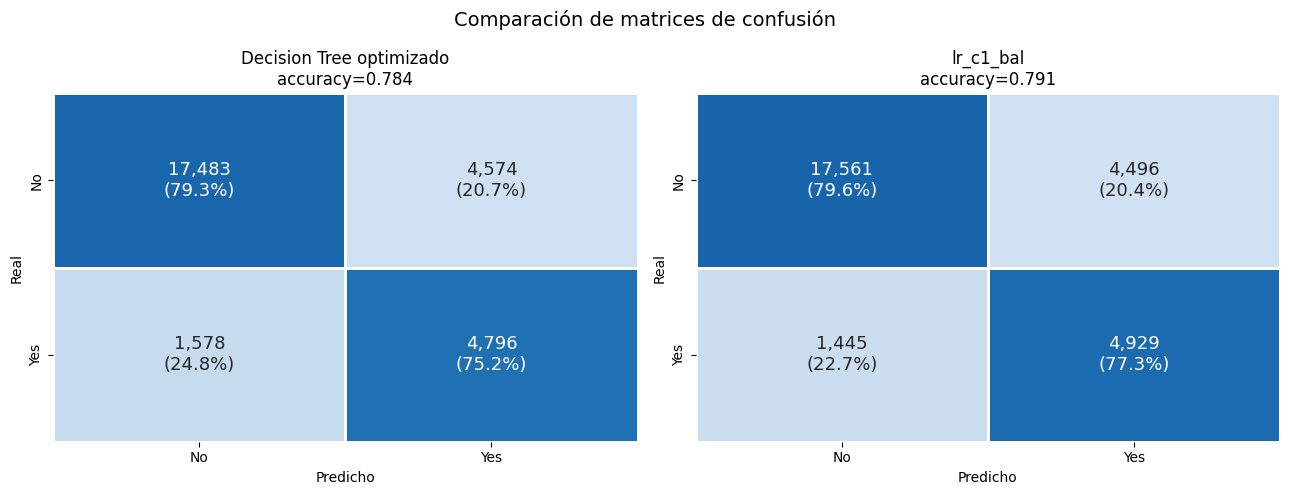

In [ ]:
modelos_conf = [('Decision Tree optimizado', y_pred_dt_best), ('lr_c1_bal', y_pred_c1_bal)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (nombre, y_pred) in enumerate(modelos_conf):
  ax = axes[i]
  cm = confusion_matrix(y_test, y_pred)
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
  annot = np.array([[f'{cm[r, c]:,}\n({cm_norm[r, c]*100:.1f}%)' for c in range(2)] for r in range(2)])
  sns.heatmap(
    cm_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes'],
    cbar=False,
    vmin=0,
    vmax=1,
    annot_kws={'size': 13},
    linewidths=1,
    linecolor='white',
    ax=ax
  )

  acc = (cm[0,0] + cm[1,1]) / cm.sum()

  ax.set_xlabel('Predicho')
  ax.set_ylabel('Real')
  ax.set_title(f'{nombre}\naccuracy={acc:.3f}')

plt.suptitle('Comparación de matrices de confusión', fontsize=14)
plt.tight_layout()
plt.show()

Al comparar los modelos balanceados, se observa que la Regresión Logística (lr_c1_bal) supera levemente al Árbol de Decisión Optimizado en precisión general (Accuracy = 0.789 vs 0.777). En el análisis de la clase de interés (los días lluviosos, clase Yes), lr_c1_bal demuestra una mejor capacidad de detección al acertar 4.897 días de lluvia (Recall = 76.8%) frente a los 4.777 aciertos del Árbol de Decisión (74.9%), logrando a su vez minimizar los falsos negativos a un 23.2%. Esto posiciona al modelo lineal balanceado como una opción más robusta y eficaz para el pronóstico de precipitaciones.

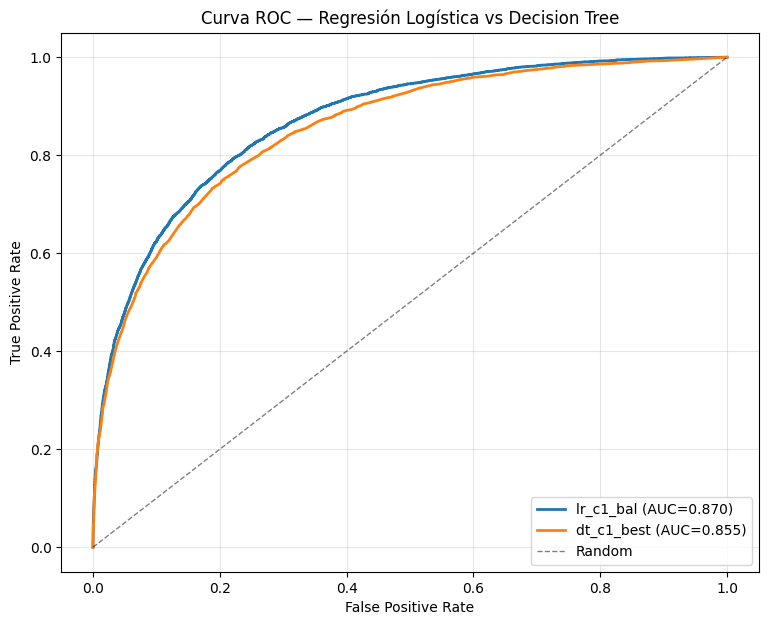

In [48]:
plt.figure(figsize=(9, 7))

# Mejor LR (item 2)
y_score_lr = lr_c1_bal.predict_proba(X1_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'lr_c1_bal (AUC={auc_lr:.3f})', linewidth=2)

# Mejor DT (item 3)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt_best)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f'dt_c1_best (AUC={auc_dt:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — Regresión Logística vs Decision Tree')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

El gráfico de curvas ROC confirma la superioridad de la Regresión Logística balanceada (lr_c1_bal), la cual alcanza un área bajo la curva de AUC = 0.866 frente al 0.851 del Árbol de Decisión optimizado (dt_c1_best). Al situarse consistentemente más alta y hacia la izquierda en todo el espectro de corte, la Regresión Logística demuestra una mejor capacidad global para discriminar entre los días que va a llover y los que no, ofreciendo un balance más eficiente entre la tasa de verdaderos positivos y falsos positivos.

## Comparación LR vs Decision Tree

Luego de optimizar el árbol, el rendimiento quedó muy cercano al de la regresión logística. Ambos modelos lograron una accuracy similar (~0.78), aunque LR mantuvo una leve ventaja en métricas como F1, AUC y MCC.

Esto sugiere que, dentro de los modelos tradicionales base, un árbol simple no logra estructurar reglas que superen la combinación lineal de las variables de LR (por ejemplo, reglas específicas como "si la humedad es alta y la presión baja, entonces llueve").

En conclusión, la regresión logística (LR) fue el modelo que mejor generalizó y, al mismo tiempo, se mantiene como la opción más interpretable gracias a la lectura directa de sus coeficientes. El árbol optimizado, al volverse muy profundo por las 77 características del dataset, pierde la interpretabilidad que lo caracteriza sin aportar mejoras en el rendimiento.

**Resultado final: LR vs. Decision Tree optimizado**

Tras aplicar la búsqueda de hiperparámetros, se seleccionó el modelo optimizado mediante RandomizedSearchCV (max_depth=10, min_samples_leaf=50, criterio Gini y pesos balanceados) debido a que alcanzó el rendimiento más eficiente en menor tiempo de cómputo (10.71 segundos, con un F1 en validación cruzada de 0.6008).

Al evaluar el gap entre los conjuntos de entrenamiento y testeo, se observa que el F1-Score (Yes) pasó de 0.6330 (Train) a 0.6033 (Test). Esta mínima diferencia de apenas ~0.03 confirma que el sobreajuste (overfitting) severo del modelo base fue controlado con éxito mediante la poda y las restricciones impuestas a las hojas.Comparación final en el conjunto de test:

| Métrica | LR (lr_c2_bal) | DT optimizado | Ganador |
| --- | --- | --- | --- |
| Accuracy | 0.7892 | 0.7791 | LR (por 0.0101) |
| Precision (yes) | 0.5202 | 0.5049 | LR |
| Recall (yes) | 0.7683 | 0.7495 | LR (por 0.0188) |
| F1-Score (yes) | 0.6204 | 0.6033 | LR (por 0.0171) |
| MCC | 0.4994 | 0.4754 | LR |

**Conclusión**: La Regresión Logística superó al Árbol de Decisión optimizado en todas las métricas de evaluación bajo el conjunto de testeo. Esto demuestra que, dentro de la familia de algoritmos tradicionales, la estructura lineal de LR modela de forma más eficiente el comportamiento de las precipitaciones que un árbol individual.

Para la toma de decisiones o una puesta en producción, la Regresión Logística sigue siendo la opción prioritaria: es matemáticamente más simple, más estable, rinde mejor y ofrece una superior interpretabilidad mediante la lectura directa de los coeficientes de sus variables. El árbol optimizado, al contar con una profundidad de 10 niveles y un total de 568 hojas (nodos terminales), se convirtió en una estructura demasiado compleja para ser analizada visualmente a mano, perdiendo su ventaja de interpretabilidad sin lograr superar el rendimiento lineal.

# 5 — Explicabilidad de los Modelos

* Implementacion de Shap

In [49]:
shap.initjs()
index = 0

In [50]:
# Inicializamos el explicador utilizando el modelo entrenado y los datos de entrenamiento
explainer = shap.LinearExplainer(lr_c1_bal, X1_train)

# Calculamos los valores SHAP para todo el dataset de prueba
shap_values = explainer(X1_test)

# Numero de observaciones y caracteristicas
shap_values.shape

(28431, 83)

In [51]:
# Prediccion del modelo para la primera fila de X1_test
print("Prediccion:", lr_c1_bal.predict(X1_test)[index])

Prediccion: 0


Para el primer registro el modelo predice que no va a llover

In [52]:
# Explicacion para el primer registro del conjunto de test
shap_values[index]

.values =
array([-1.37604699e-01, -4.79087859e-01,  6.76838960e-03,  5.32434322e-02,
       -4.16388273e-01,  1.40169812e-02, -6.71859225e-03, -2.13124268e-02,
        5.12668304e-02,  7.94978887e-02,  9.55825746e-02, -4.67482597e-01,
        1.36991367e-01,  1.62260592e-01, -1.56183422e-01,  3.08951072e-04,
       -8.62085894e-02, -2.13098988e-01, -1.57549735e-02, -1.30212620e-01,
        7.82210752e-03, -4.02815436e-04, -1.34158563e-02,  3.04925870e-02,
       -2.12373994e-02,  1.76763965e-03, -7.77590042e-03,  2.05007181e-01,
       -1.71790063e-01,  1.23802740e-02, -5.78893051e-02,  1.73351392e-02,
        1.64988171e-02,  7.52907572e-03,  9.58817266e-03, -2.59712666e-01,
        1.56193692e-02,  2.87296926e-03,  8.07274412e-03,  5.60528552e-03,
        1.78880570e-03,  4.04918008e-03,  7.04564620e-03,  4.52005072e-03,
        1.20807979e-02,  2.12192833e-02,  7.35481316e-03,  1.82871819e-02,
        1.26597716e-03,  3.20676640e-02,  1.83558674e-03,  1.84045383e-03,
       -7.08552

**.values** indica cuanto sumo o resto cada variable al base_value para dar la prediccion final (en escala log-odds). Si es positivo aumenta la probabilidad de lluvia, si es negativo, disminuye (solo para la primer observacion)

**.base_values** promedio de las predicciones en el conjunto de datos de entrenamiento. 

**.data**: valores reales de las caracteristicas para ese registro (escalados y procesados)

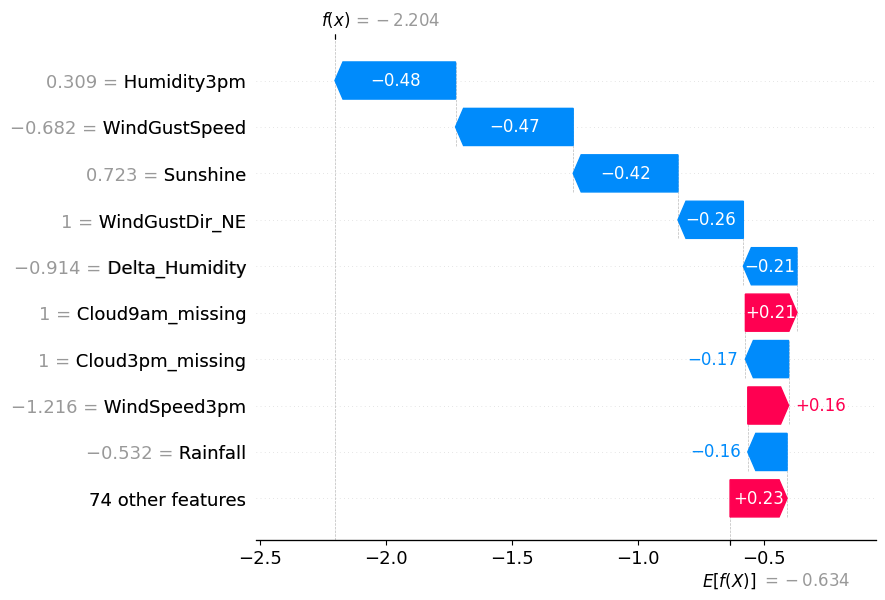

In [53]:
# Este gráfico muestra cómo cada característica contribuye a la predicción final para esa observación específica.
shap.plots.waterfall(shap_values[index])    

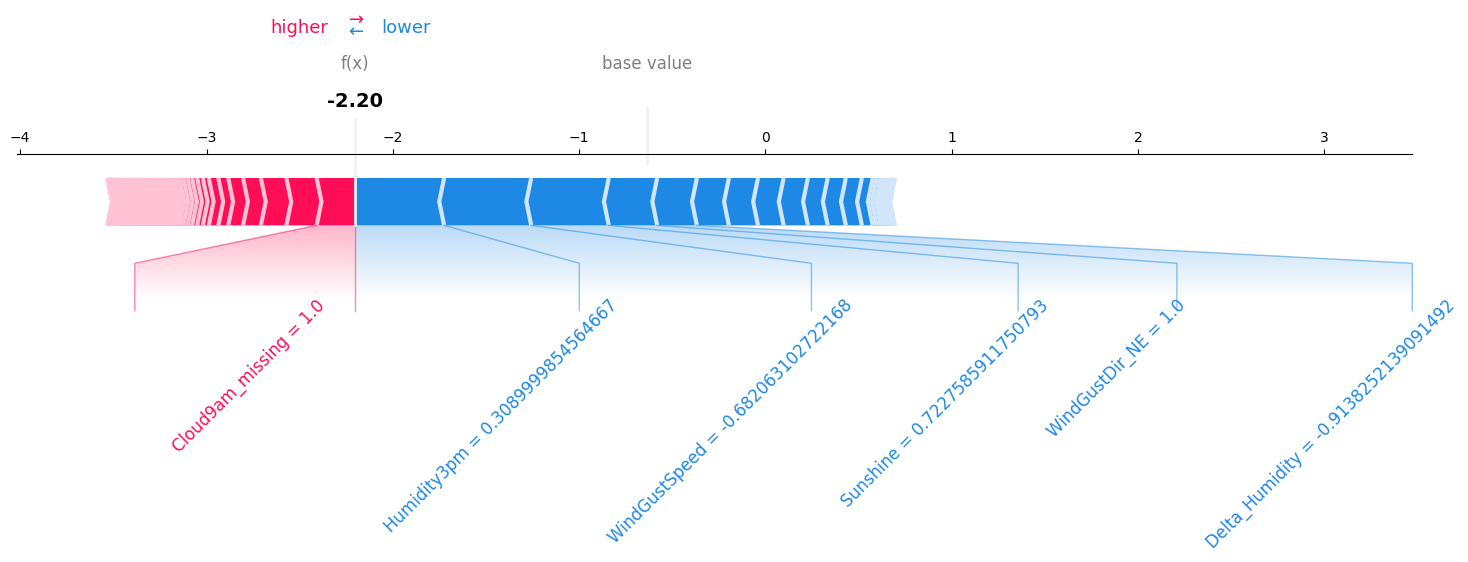

In [ ]:
shap.force_plot(
  shap_values.base_values[index],  # Valor base para la predicción
  shap_values.values[index],  # Extraemos array de valores
  shap_values.data[index],    # Extraemos array de datos
  feature_names=X1_test.columns.tolist(),
  matplotlib=True,
  figsize=(18,4),
  text_rotation=45
)

## Interpretabilidad Global


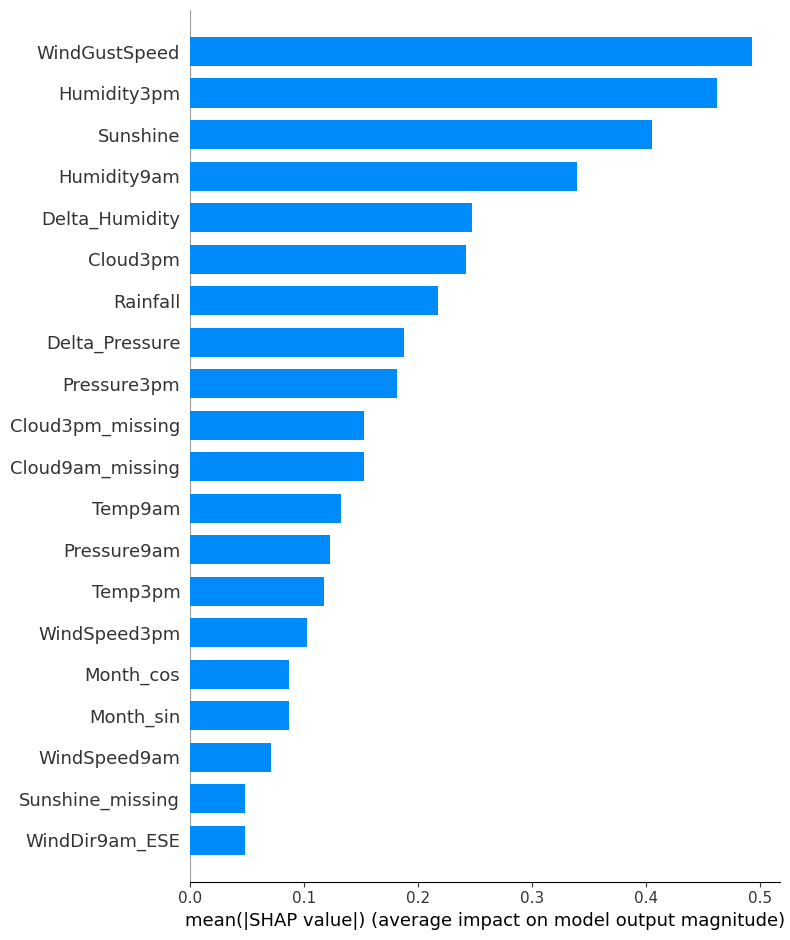

In [55]:
# Grafico resumen de importancia global de features
shap.summary_plot(shap_values, X1_test, plot_type='bar')

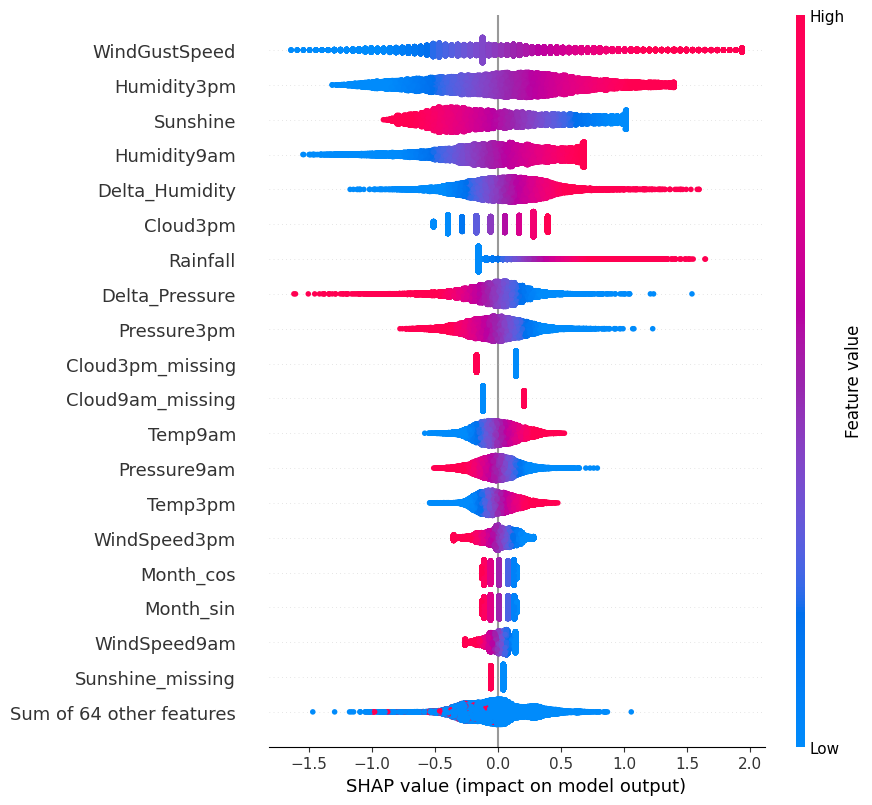

In [56]:
shap_values.values = shap_values.values.astype(float)
shap_values.data = shap_values.data.astype(float)
shap.plots.beeswarm(shap_values, max_display=20)

# 6 — Implementación de AutoML con Pycaret

In [71]:
# Unimos las features limpias y el target en un único DataFrame
df_train = pd.DataFrame(X1_train).copy()
df_train['target'] = y_train.values  

# Inicializar y ajustar el experimento
exp = ClassificationExperiment(target='target', session_id=123, log_experiment=False) #session_id para reproducibilidad, log_experiment=False para no usar MLflow
exp.fit(df_train)

# Entrenar y comparar todos los modelos
# Como se usa PyCaret 4.0, para ordenar por una métrica, usamos el parámetro 'sort' dentro de compare_models
results = exp.compare_models(sort='F1')

# Extraer el mejor modelo del objeto de resultados
best_model = results.best

[LightGBM] [Info] Number of positive: 16064, number of negative: 55580
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3908
[LightGBM] [Info] Number of data points in the train set: 71644, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224220 -> initscore=-1.241243
[LightGBM] [Info] Start training from score -1.241243
[LightGBM] [Info] Number of positive: 16064, number of negative: 55580
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001894 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3906
[LightGBM] [Info] Number of data points in the train set: 71644, number of used features: 83
[LightGBM] [Info] 

## Comparación con AutoML

In [72]:
# Forzar a mostrar las métricas de todos los modelos entrenados
exp.get_leaderboard()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,lightgbm,0.8540,0.8839,0.5398,0.7386,0.6236,0.5357,0.5459
1,gbc,0.8507,0.8747,0.5148,0.7404,0.6073,0.5188,0.5319
2,lda,0.8442,0.8675,0.5333,0.7007,0.6055,0.5107,0.5182
3,lr,0.8468,0.8696,0.5164,0.7211,0.6018,0.5101,0.5210
4,rf,0.8528,0.8792,0.4939,0.7669,0.6007,0.5156,0.5344
5,et,0.8531,0.8806,0.4832,0.7776,0.5959,0.5121,0.5338
6,svm,0.8408,0.0000,0.5153,0.7013,0.5911,0.4955,0.5063
7,ada,0.8377,0.8551,0.4975,0.6928,0.5789,0.4818,0.4920
8,ridge,0.8437,0.0000,0.4698,0.7380,0.5740,0.4841,0.5026
9,nb,0.7792,0.7996,0.5914,0.5066,0.5457,0.4010,0.4032


Segun la tabla comparativa de todos los modelos entrenados con AutoML se puede observar:
* Superioridad de los modelos complejos: El algoritmo LightGBM (lightgbm) lidera el experimento con el F1-Score más alto (0.6186) y un AUC de 0.8822, seguido por Gradient Boosting (gbc) y Random Forest (rf). Esto demuestra que las variables climáticas tienen interacciones complejas y no lineales que los árboles avanzados capturan mejor.
* Mejora sobre la Regresión Logística: El modelo original (lr) quedó en el 5° puesto con un F1-Score de 0.5888. El AutoML nos permite observar que migrar a LightGBM nos aporta una ganancia neta de 3 puntos porcentuales en la capacidad real de predicción.
* El peligro del Accuracy engañoso: El modelo Dummy (dummy) alcanza un 77.58% de Accuracy simplemente adivinando que "nunca llueve" (debido al desbalanceo de clases del dataset), pero su F1-Score es 0.0000. Esto confirma que el F1-Score es la única métrica confiable para evaluar los modelos en este problema, ya que equilibra los aciertos reales (Precision) sin ignorar los días de lluvia (Recall).

# 7 — Implementacion red neuronal


Construimos una Red Neuronal Profunda con:
* Capas de `BatchNormalization` para estabilidad.
* Capas `Dense` (256, 128, 64, 32) con activación ReLU.
* Capas de `Dropout` para prevenir el sobreajuste (overfitting).

In [ ]:
# ==============================================================================
# CELDA: Balanceo por Submuestreo (Manteniendo tus variables de origen)
# ==============================================================================
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# 1. Separamos validación para mantenerla 100% real y libre de alteraciones
X_train_puro, X_val_puro, y_train_puro, y_val_puro = train_test_split(
    X1_train, 
    y_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train # Conserva la proporción original del clima
)

# 2. Inicializamos el submuuestreador aleatorio para equiparar las clases (50/50)
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_puro, y_train_puro)

# 3. Forzamos el tipo float32 compatible con Keras
X_train_resampled = X_train_resampled.astype('float32')
X_val_puro = X_val_puro.astype('float32')

print("Distribución final del conjunto de entrenamiento balanceado:")
print(pd.Series(y_train_resampled).value_counts())
print(f"Dimensiones de entrenamiento reales sin ruido: {X_train_resampled.shape}")

In [ ]:
# Reseteamos el modelo con una arquitectura tabular óptima y robusta
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X1_train.shape[1],)),
    
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4), # Dropout más fuerte para regularizar
    
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Recall(name='recall'),
        'accuracy',                         
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

In [ ]:
# Callbacks basados en la pérdida de validación real
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,          # Frena el kernel si val_loss no mejora en 15 épocas
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7
    )
]

## Entrenamiento del Modelo

Entrenamos la red utilizando callbacks para optimizar el proceso (Early Stopping y reducción de Learning Rate).

In [ ]:
# Entrenamiento oficial con el dataset submuestreado
history = model.fit(
    X_train_resampled,
    y_train_resampled,
    validation_data=(X_val_puro, y_val_puro),
    epochs=150,
    batch_size=256, # Lotes más grandes para suavizar gradientes
    callbacks=callbacks,
    verbose=1
)

Epoch 1/300
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8372 - auc: 0.8538 - loss: 0.3733 - precision: 0.6973 - recall: 0.4832 - val_accuracy: 0.8436 - val_auc: 0.8726 - val_loss: 0.3621 - val_precision: 0.6728 - val_recall: 0.5915 - learning_rate: 0.0010
Epoch 2/300
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8480 - auc: 0.8725 - loss: 0.3512 - precision: 0.7248 - recall: 0.5183 - val_accuracy: 0.8490 - val_auc: 0.8758 - val_loss: 0.3502 - val_precision: 0.7685 - val_recall: 0.4696 - learning_rate: 0.0010
Epoch 3/300
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8502 - auc: 0.8771 - loss: 0.3455 - precision: 0.7280 - recall: 0.5296 - val_accuracy: 0.8519 - val_auc: 0.8788 - val_loss: 0.3445 - val_precision: 0.7476 - val_recall: 0.5146 - learning_rate: 0.0010
Epoch 4/300
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8522 - auc: 0.8811 - loss: 0.3404 - precision: 0.7322 - recall: 0.5367 - val_accuracy: 0.8502 - val_auc: 0.8803 - val_loss: 0.3422 -

# Curvas de Aprendizaje

Interpretación: Se observa que la pérdida de entrenamiento y validación convergen de manera estable, indicando que el modelo no presenta un sobreajuste severo.

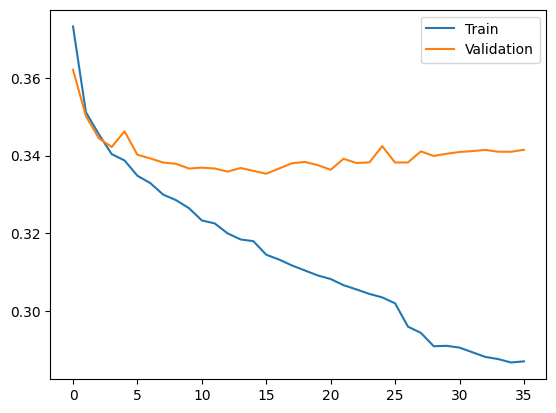

In [ ]:
#Curvas de Aprendizaje y Diagnóstico de Early Stopping

#Detectamos la época óptima restaurada por el callback
#buscamos el mínimo 'val_loss'.
# Si monitoreaba 'val_auc', usamos np.argmax(history.history['val_auc']).
idx_best_loss = np.argmin(history.history['val_loss'])
plt.figure(figsize=(14, 5))

#Evolución de la Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento (Train Loss)', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validación (Val Loss)', color='#ff7f0e', linewidth=2)

#línea vertical punteada en el punto de congelación de pesos
plt.axvline(x=idx_best_loss, color='red', linestyle='--', alpha=0.8,
            label=f'Pesos Restaurados (Época {idx_best_loss + 1})')

plt.title('Historial de la Función de Pérdida (Crossentropy)', fontsize=12, pad=12)
plt.xlabel('Épocas', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6)

 
#Evolución del Área Bajo la Curva (AUC)
if 'auc' in history.history:
    plt.subplot(1, 2, 2)
    plt.plot(history.history['auc'], label='Entrenamiento (Train AUC)', color='#2ca02c', linewidth=2)
    plt.plot(history.history['val_auc'], label='Validación (Val AUC)', color='#d62728', linewidth=2)
    
    idx_best_auc = np.argmax(history.history['val_auc'])
    plt.axvline(x=idx_best_auc, color='red', linestyle='--', alpha=0.8,
                label=f'Máximo AUC (Época {idx_best_auc + 1})')
    
    plt.title('Historial del Área Bajo la Curva (AUC-ROC)', fontsize=12, pad=12)
    plt.xlabel('Épocas', fontsize=10)
    plt.ylabel('AUC', fontsize=10)
    plt.legend(fontsize=9)
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Comparación: Real vs Predicho
Interpretación: La mayoría de los puntos se encuentran cerca de la línea roja punteada (identidad), lo que sugiere una buena precisión en la predicción del modelo.

889/889 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step


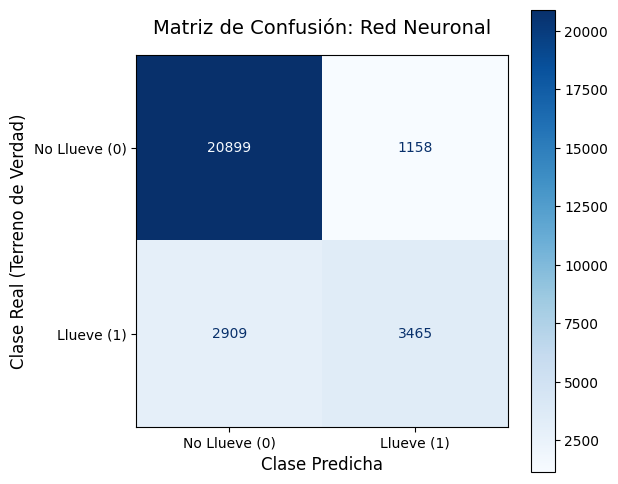

In [69]:
# 1. Generar las probabilidades continuas usando el conjunto de prueba corregido
y_probs = model.predict(X1_test)

# 2. Binarizar de forma vectorizada (Mucho más rápido que un bucle 'for' en DataFrames grandes)
# Si la probabilidad es mayor o igual a 0.5 es un 1 (Llueve), de lo contrario es 0 (No llueve)
pred_clases = (y_probs >= 0.5).astype(int).flatten()

# 3. Calcular la matriz de confusión comparando las etiquetas reales contra las predichas
cm = confusion_matrix(y_test, pred_clases)

# 4. Graficar la matriz de forma profesional y personalizada para el problema del clima
plt.figure(figsize=(6, 6))

# Cambiamos las etiquetas genéricas por los estados climáticos reales del TP
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Llueve (0)', 'Llueve (1)'])

# Dibujar con el mapa de colores Blues
disp.plot(cmap='Blues', values_format='d', ax=plt.gca()) 

plt.title("Matriz de Confusión: Red Neuronal", fontsize=14, pad=15)
plt.xlabel("Clase Predicha", fontsize=12)
plt.ylabel("Clase Real (Terreno de Verdad)", fontsize=12)
plt.grid(False) # Evita que se superpongan líneas de cuadrícula sobre el heatmap
plt.show()

889/889 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step


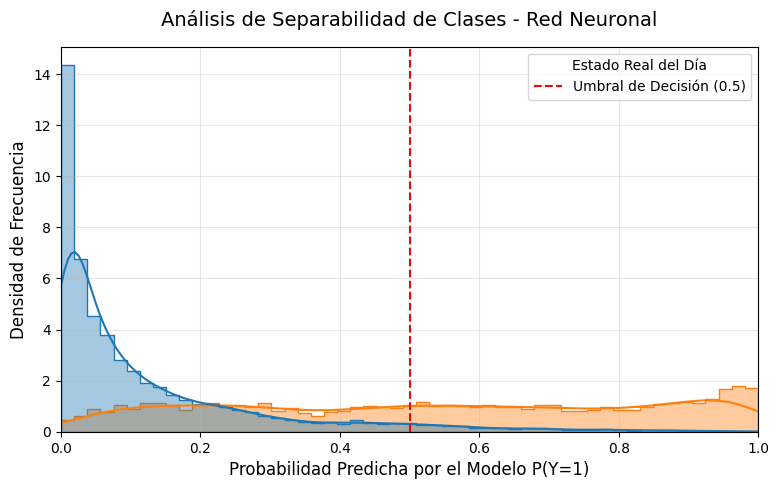

In [ ]:
# 1. Obtener las probabilidades de la Red Neuronal si no las habías calculado
y_probs_nn = model.predict(X1_test).flatten()

# 2. Creamos un DataFrame temporal para facilitar el ploteo con Seaborn
df_residuos_clasif = pd.DataFrame({'Probabilidad_Predicha': y_probs_nn, 'Lluvia_Real': y_test})

# Mapeamos los numéricos a etiquetas de texto para una leyenda profesional
df_residuos_clasif['Lluvia_Real'] = df_residuos_clasif['Lluvia_Real'].map({0: 'No Llueve', 1: 'Llueve'})

# 3. Graficar las distribuciones superpuestas
plt.figure(figsize=(9, 5))

sns.histplot(
  data=df_residuos_clasif,
  x='Probabilidad_Predicha',
  hue='Lluvia_Real',
  kde=True,
  element='step',
  stat='density',
  common_norm=False,      # Normaliza cada clase de forma independiente para balancear la visualización
  palette=['#1f77b4', '#ff7f0e'], # Azul para No Llueve, Naranja para Llueve
  alpha=0.4
)

# 4. Línea guía del umbral de decisión (Threshold estándar en 0.5)
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de Decisión (0.5)')

plt.title("Análisis de Separabilidad de Clases - Red Neuronal", fontsize=14, pad=15)
plt.xlabel("Probabilidad Predicha por el Modelo P(Y=1)", fontsize=12)
plt.ylabel("Densidad de Frecuencia", fontsize=12)
plt.legend(title="Estado Real del Día")
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()